# Tugas Besar IF3270 Pembelajaran Mesin
## Feedforward Neural Network

**Nama Anggota:**
- 13523135 - Ahmad Syafiq
- 13523152 — Muhammad Kinan Arkansyaddad
- 13523162 — Fachriza Ahmad Setiyono

**Kelas:** 3

---

## 0. Import Libraries & Load Data

In [31]:
!pip install -r ../requirements.txt

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score
from models.nn import FFNN

# tambahkan import lainnya sesuai kebutuhan

RANDOM_STATE = 42

In [33]:
# Load dataset
file_path = '../data/datasetml_2026.csv'

train_df = pd.read_csv(file_path)

print("Train shape:", train_df.shape)

Train shape: (10000, 12)


---
## 1. Exploratory Data Analysis (EDA)

> **Tujuan:** Memahami data secara mendalam sebelum preprocessing dan modeling.
> **Requirement:** Minimal **3 visualisasi** dengan **3 pertanyaan** (1 per visualisasi).

### 1.1 Gambaran Umum Dataset

In [34]:
train_df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [35]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [36]:
TARGET_COL = 'placement_status'
NUM_COLS = ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']
ORDINAL_COLS = ['college_tier', 'university_ranking_band']
CATEGORICAL_COLS = ['country', 'specialization', 'industry']

In [37]:
train_df.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,10000.000000,10000.000000,10000,10000,10000,10000.00000,10000.000000,10000.000000,10000,10000,10000.000000,10000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,Germany,300+,NaN,NaN,NaN,Data Science,Consulting,NaN,Placed
freq,NaN,NaN,3993,2057,4075,NaN,NaN,NaN,2036,1739,NaN,6153
mean,6.998290,1.248100,NaN,NaN,NaN,1.49930,69.877531,65.158600,NaN,NaN,5.021436,NaN
std,0.802606,1.149904,NaN,NaN,NaN,1.20289,14.700532,14.740446,NaN,NaN,1.505975,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.00000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.461928,0.000000,NaN,NaN,NaN,1.00000,59.880399,55.112244,NaN,NaN,4.012656,NaN
50%,6.997924,1.000000,NaN,NaN,NaN,1.00000,70.097368,65.006484,NaN,NaN,5.017335,NaN
75%,7.536865,2.000000,NaN,NaN,NaN,2.00000,80.213934,75.277248,NaN,NaN,6.031400,NaN


In [38]:
# Cek missing values
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [39]:
# Distribusi kelas target
print(train_df[TARGET_COL].value_counts())

placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64


### 1.2 Visualisasi 1 — Distribusi Kelas

*Pertanyaan:* Apakah proporsi kelas pada dataset seimbang atau imbalanced?

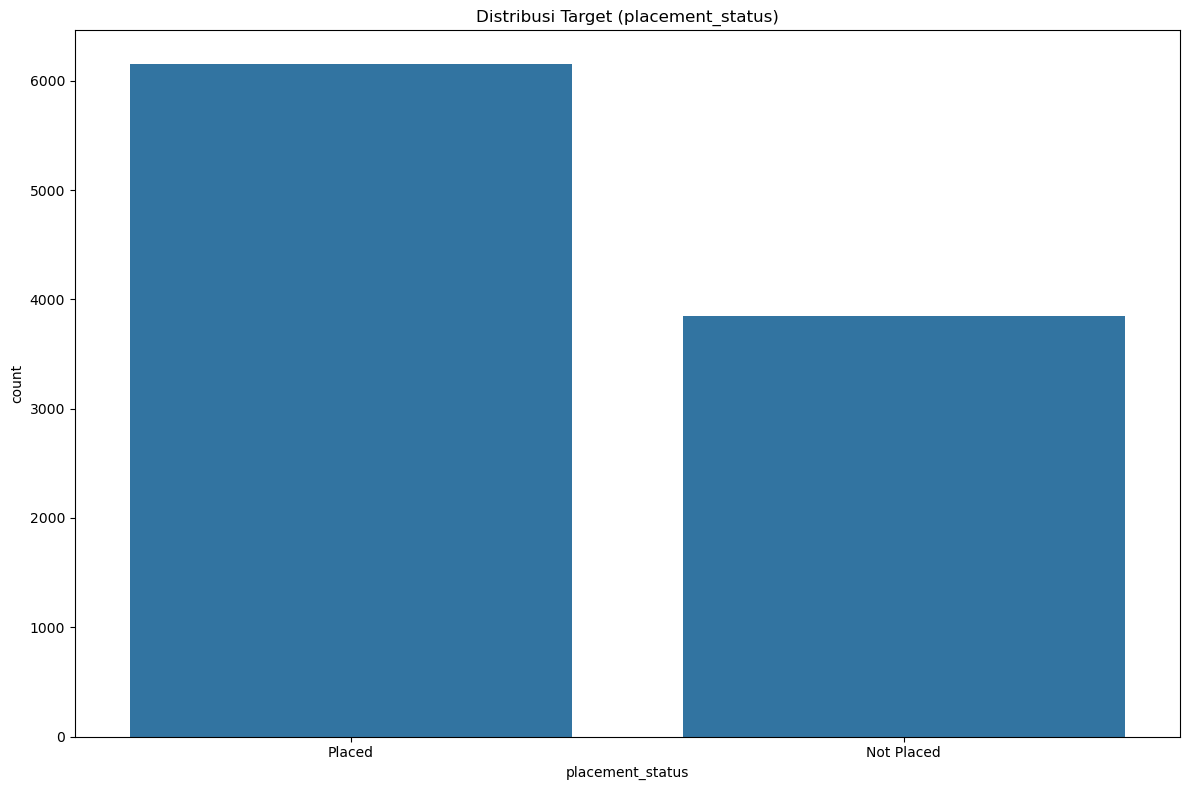

In [40]:
fig, axes = plt.subplots(1, 1, figsize=(12, 8))

sns.countplot(data=train_df, x=TARGET_COL, ax=axes)
axes.set_title('Distribusi Target (placement_status)')

plt.tight_layout()
plt.show()

**Analisis:** a

### 1.3 Visualisasi 2 — *Outlier* dataset

*Pertanyaan:* Apakah ada *outlier* pada target dataset terhadap fitur dataset?

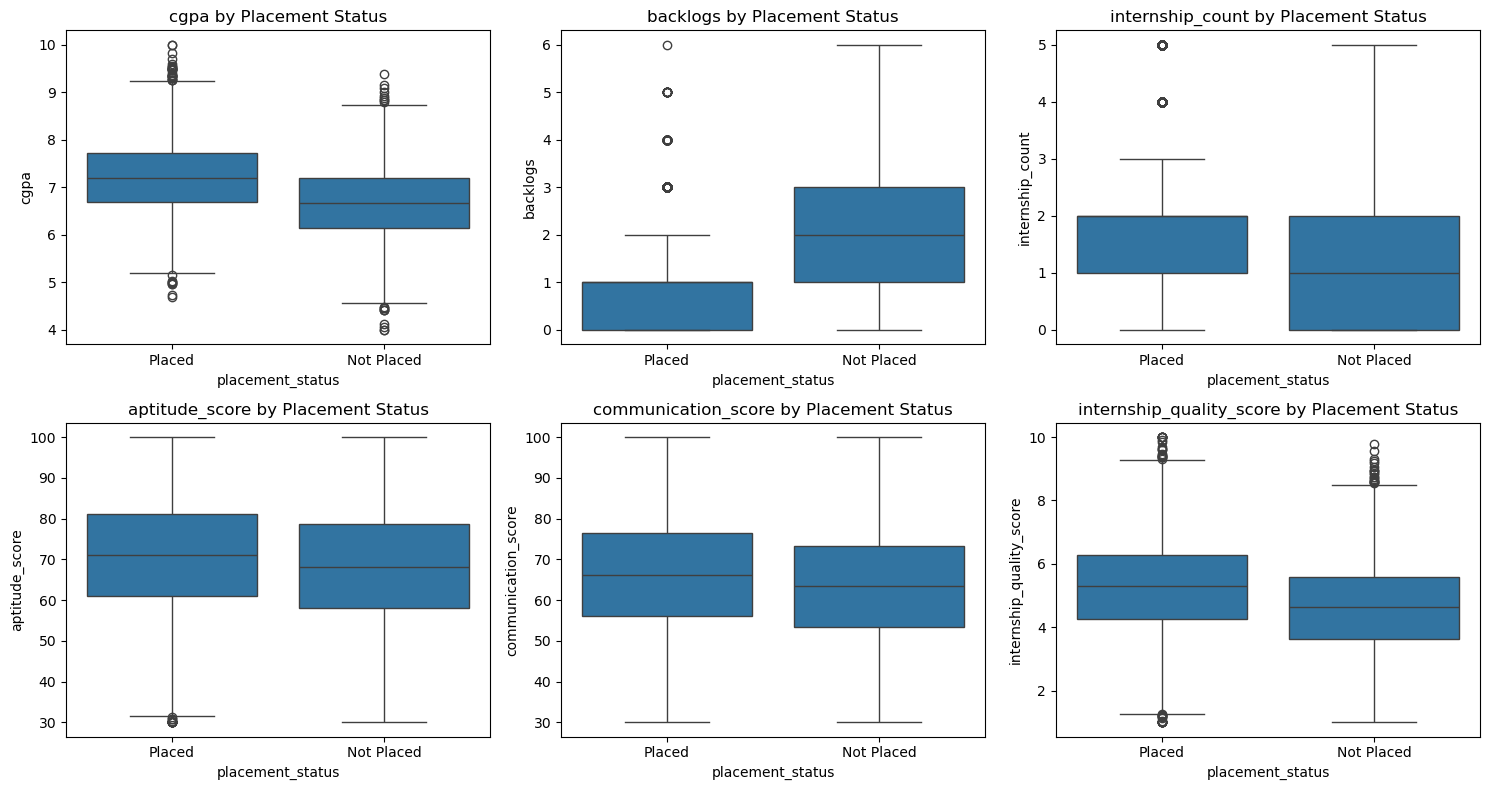

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), NUM_COLS):
    sns.boxplot(data=train_df, x=TARGET_COL, y=col, ax=ax)
    ax.set_title(f'{col} by Placement Status')
plt.tight_layout()
plt.show()

**Analisis:** Dari diagram *boxplot* .

### 1.4 Visualisasi 2 — Hubungan Kolom Kategorikal dengan Kelas Target

*Pertanyaan:* Bagaimana korelasi antara kelas target dengan kolom kategorikal?

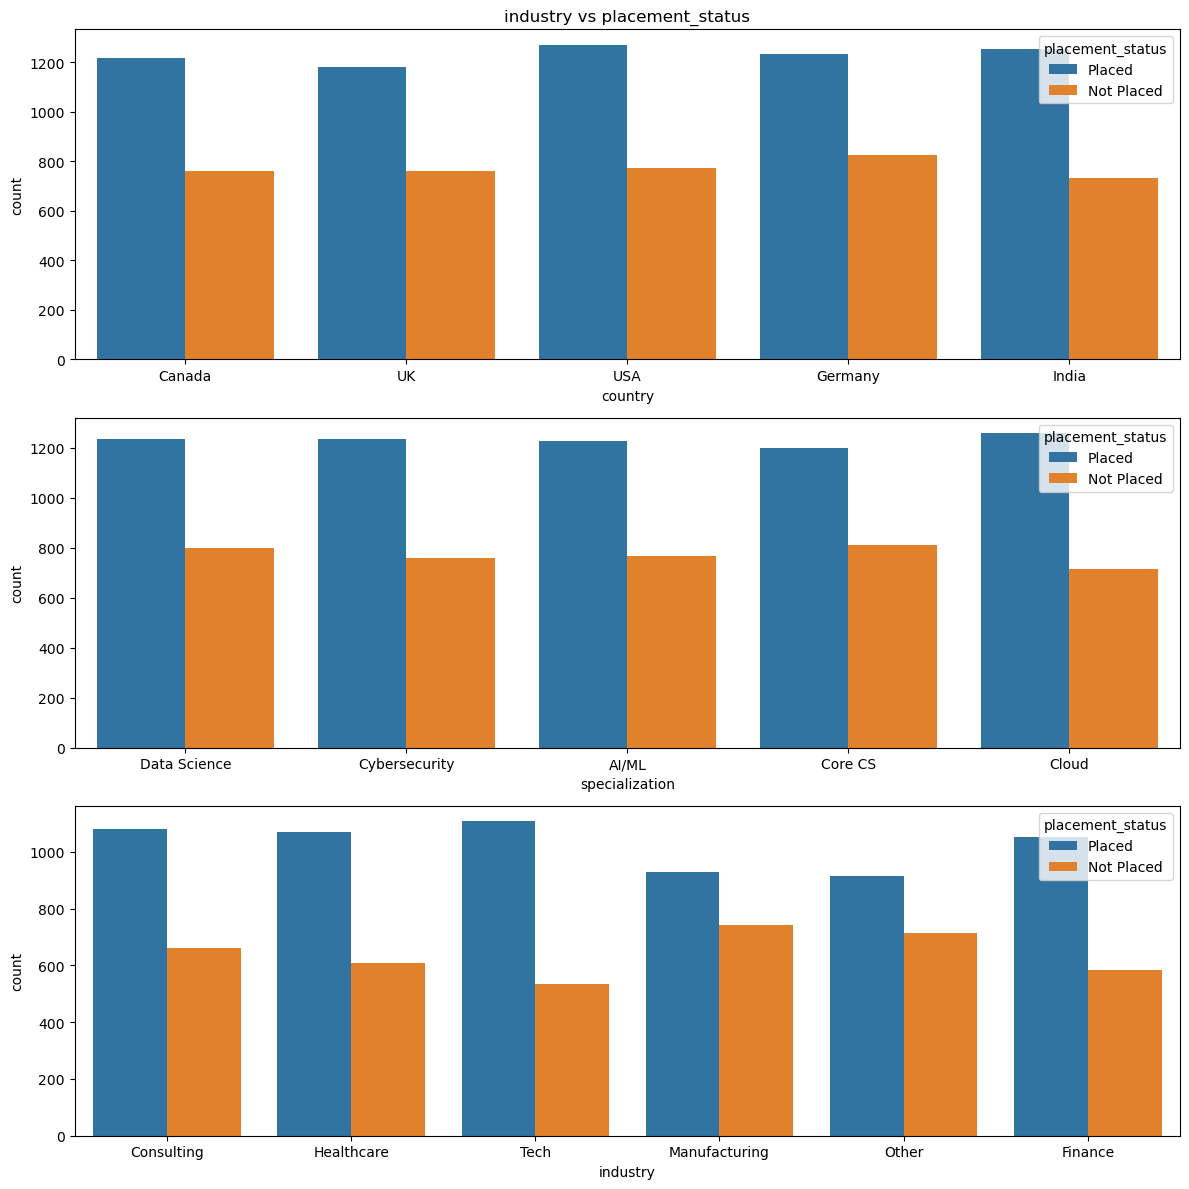

In [42]:
fig, axes = plt.subplots(len(CATEGORICAL_COLS), 1, figsize=(12, 12))


for i in range(len(CATEGORICAL_COLS)):
    sns.countplot(data=train_df, x=CATEGORICAL_COLS[i], hue=TARGET_COL, ax=axes[i])
    axes[0].set_title(f'{CATEGORICAL_COLS[i]} vs {TARGET_COL}')

plt.tight_layout()
plt.show()

**Analisis:**
Dari grafik tersebut, terlihat 

### 1.5 Heatmap Korelasi antar Fitur Numerik

*Pertanyaan:* Bagaimana korelasi antara fitur numerik dataset?

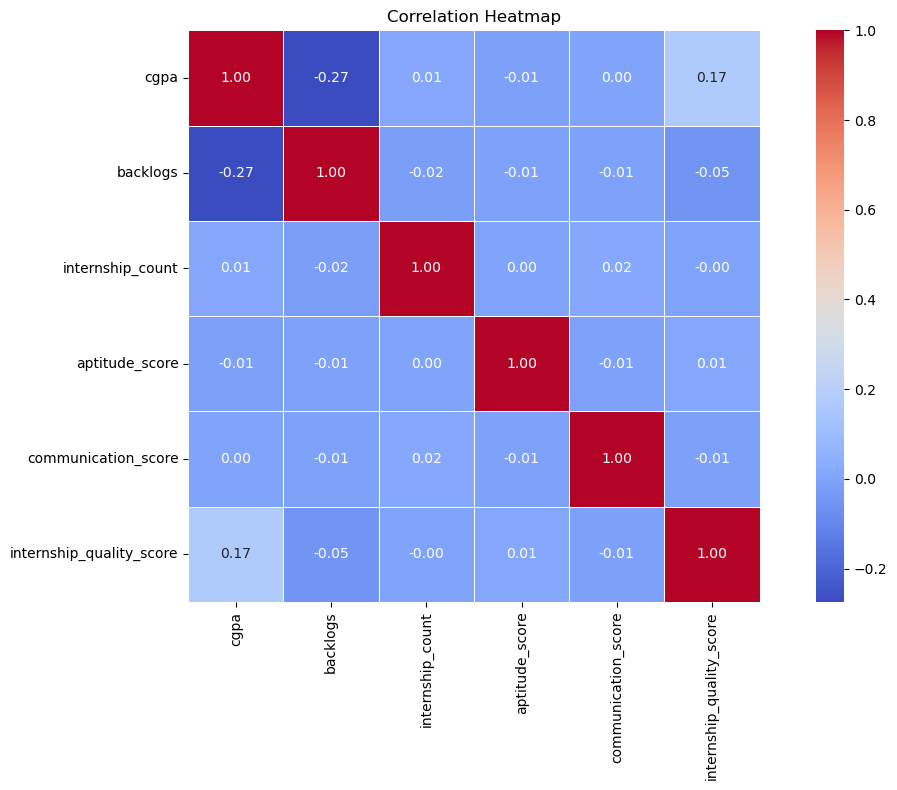

In [43]:
plt.figure(figsize=(12, 8))
corr_matrix = train_df[NUM_COLS].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Analisis:** *Heatmap* menunjukkan

---
## 2. Data Cleaning and Preprocessing

> **Tujuan:** Menyiapkan data untuk training model.
> **Requirement:** Sertakan **penjelasan** untuk setiap langkah.

> ⚠️ **Ingat:** Fit transformer **hanya pada training data**, lalu transform train dan test secara terpisah untuk menghindari data leakage.

In [44]:
# TARGET_COL, NUM_COLS, ORDINAL_COLS, CATEGORICAL_COLS sudah terdefinisi

print("Categorical:", CATEGORICAL_COLS)
print("Numerical:  ", NUM_COLS)

X = train_df.drop(TARGET_COL, axis=1)
y = train_df[TARGET_COL]


Categorical: ['country', 'specialization', 'industry']
Numerical:   ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


### 2.1 Pisahkan Fitur (X) dan Target (y)

In [45]:
X = train_df.drop(columns=[TARGET_COL])
y = train_df[TARGET_COL]

### 2.2 Handling Outliers

**Penjelasan:** *[Apakah Anda menangani outlier? Metode dan alasannya?]*

In [46]:
# for col in NUM_COLS:
#     Q1 = train[col].quantile(0.25)
#     Q3 = train[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     # Menghitung jumlah yang terdampak (opsional untuk log)
#     outliers = ((train[col] < lower_bound) | (train[col] > upper_bound)).sum()
#     print(f" - {col}: {outliers} outlier dideteksi")

#     # Clipping data train dan test menggunakan bound dari train
#     train[col] = train[col].clip(lower=lower_bound, upper=upper_bound)
#     test[col]  = test[col].clip(lower=lower_bound, upper=upper_bound)

### 2.3 Preprocessing Pipeline

In [47]:
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)

college_tiers = ['Tier 3', 'Tier 2', 'Tier 1']
ranking_bands = ['300+', '100-300', 'Top 100']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[college_tiers, ranking_bands]))
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 7. Combine all steps into a ColumnTransformer Preprocessor
preprocessor = ColumnTransformer([
    ('num', num_pipeline, NUM_COLS),
    ('ord', ordinal_pipeline, ORDINAL_COLS),
    ('cat', nominal_pipeline, CATEGORICAL_COLS)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, NUM_COLS),
        ('ord', ordinal_pipeline, ORDINAL_COLS),
        ('cat', nominal_pipeline, CATEGORICAL_COLS)
    ])

X_preprocessed = preprocessor.fit_transform(X)

### 2.4 Feature Scaling

**Penjelasan:** *[Apakah perlu scaling? Untuk model apa? Metode yang dipilih?]*

### 2.5 (Opsional) Feature Engineering / Selection

### 2.6 Train-Validation Split

In [48]:
# Pembagian Dataset (Train: 70%, Val: 15%, Test: 15%)
X_temp, X_test, y_temp, y_test = train_test_split(X_preprocessed, y_encoded, test_size=0.15, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=RANDOM_STATE)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)
print("X_test:  ", X_test.shape,   "| y_val:  ", y_test.shape)

X_train: (6999, 24) | y_train: (6999,)
X_val:   (1501, 24) | y_val:   (1501,)
X_test:   (1500, 24) | y_val:   (1500,)


### 2.7 Reshape target ke bentuk matriks (N, 1) dan ubah ke float64 untuk model custom FFNN

In [49]:
y_train = y_train.reshape(-1, 1).astype(np.float64)
y_val = y_val.reshape(-1, 1).astype(np.float64)
y_test = y_test.reshape(-1, 1).astype(np.float64)

X_train = X_train.astype(np.float64)
X_val = X_val.astype(np.float64)
X_test = X_test.astype(np.float64)
nin = X_train.shape[1] # Ukuran input layer (banyak fitur)

print("Dimensi X_train:", X_train.shape)
print("Dimensi y_train:", y_train.shape)

Dimensi X_train: (6999, 24)
Dimensi y_train: (6999, 1)


---
## 3. Pengujian

> **Metrik utama:** Macro F1-Score

In [50]:
from sklearn.metrics import accuracy_score


def plot_loss_curve(history, title="Training and Validation Loss"):
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    if len(history['val_loss']) > 0:
        plt.plot(history['val_loss'], label='Val Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (BCE)')
    plt.legend()
    plt.grid(True)
    plt.show()

def evaluate_model(model, X, y, threshold=0.5):
    preds = model.predict(X)
    preds_class = (preds >= threshold).astype(int)
    print(f"Accuracy: {accuracy_score(y, preds_class):.4f}")
    print(classification_report(y, preds_class, target_names=['Not Placed (0)', 'Placed (1)'], zero_division=0))

### 3.1 Hyperparameter

#### 3.1.1 Pengaruh depth (banyak layer) dan width (banyak neuron per layer)

 EKSPERIMEN VARIASI WIDTH (DEPTH TETAP) 
Training Model Width: 8 neurons
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x000002393526DC10>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023935EADA90>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023935EAFA90>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023935E4A110>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x0000023934FC5710>
Epoch 1/30
219/219 [------------------------------] - loss: 1.5895 - val_loss: 1.1912
Epoch 2/30
219/219 [------------------------------] - loss: 1.0458 - val_loss: 0.9535
Epoch 3/30
219/219 [------------------------------] - loss: 0.8863 - val_loss: 0.8484
Epoch 4/30
219/219 [------------------------------] - loss: 0.8072 - val_loss: 0.7964
Epoch 5/30
219/219 [------------------------------] - loss: 0.7627 - val_loss: 0.7587
Epoch 6/30
219/219 

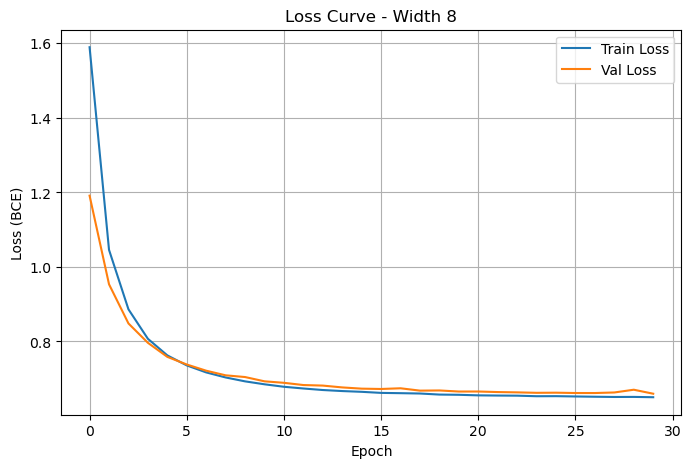


[Evaluasi Validation] Model Width 8:
Accuracy: 0.6129
                precision    recall  f1-score   support

Not Placed (0)       0.55      0.13      0.21       594
    Placed (1)       0.62      0.93      0.74       907

      accuracy                           0.61      1501
     macro avg       0.58      0.53      0.47      1501
  weighted avg       0.59      0.61      0.53      1501


[Distribusi] Model Width 8 - Hidden Layer Terakhir


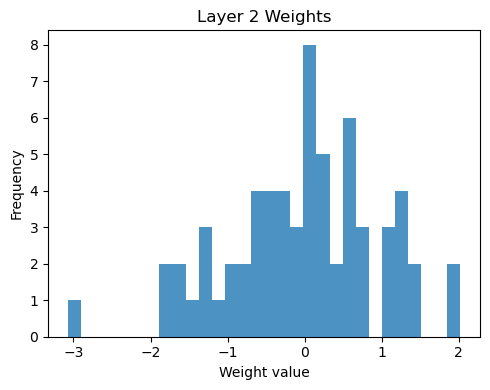

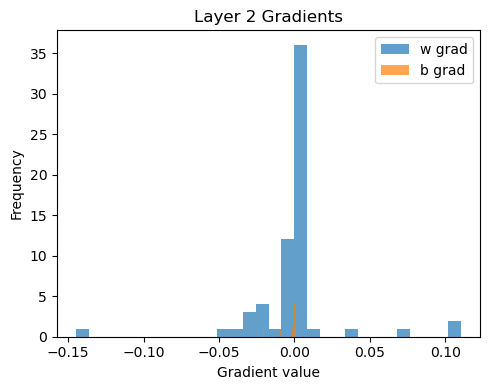

Training Model Width: 16 neurons
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x0000023934E5F450>
activation name set relu
activation set <models.activations.ReLU object at 0x000002396AD0EE10>
activation name set relu
activation set <models.activations.ReLU object at 0x000002393F477510>
activation name set relu
activation set <models.activations.ReLU object at 0x000002394A943B90>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x000002393A551910>
Epoch 1/30
219/219 [------------------------------] - loss: 5.0833 - val_loss: 2.1727
Epoch 2/30
219/219 [------------------------------] - loss: 1.7756 - val_loss: 1.4008
Epoch 3/30
219/219 [------------------------------] - loss: 1.2324 - val_loss: 1.3882
Epoch 4/30
219/219 [------------------------------] - loss: 1.0412 - val_loss: 0.8826
Epoch 5/30
219/219 [------------------------------] - loss: 0.8922 - val_loss: 0.8922
Epoch 6/30
219/219 [------------------------------] - loss:

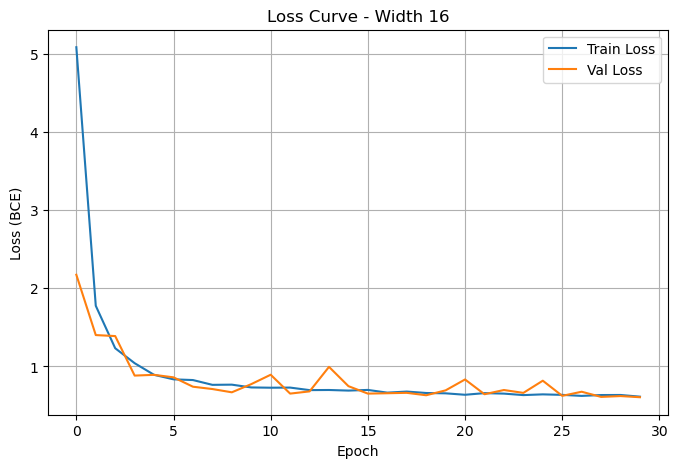


[Evaluasi Validation] Model Width 16:
Accuracy: 0.6676
                precision    recall  f1-score   support

Not Placed (0)       0.59      0.51      0.55       594
    Placed (1)       0.71      0.77      0.74       907

      accuracy                           0.67      1501
     macro avg       0.65      0.64      0.64      1501
  weighted avg       0.66      0.67      0.66      1501


[Distribusi] Model Width 16 - Hidden Layer Terakhir


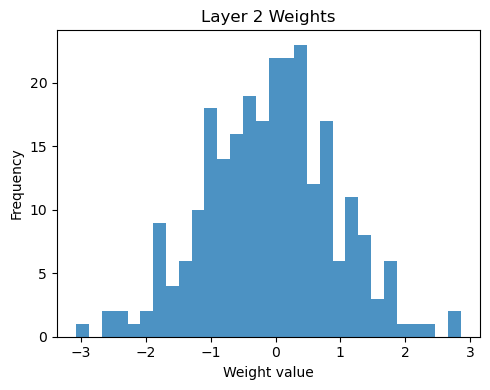

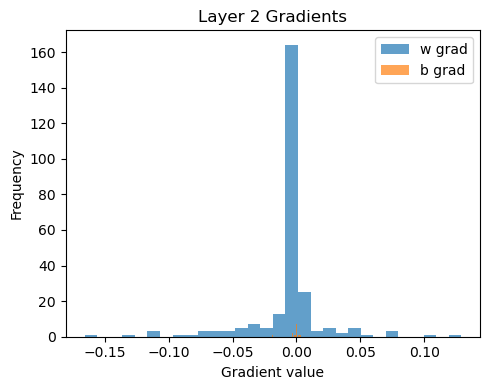

Training Model Width: 32 neurons
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x0000023934E5EA90>
activation name set relu
activation set <models.activations.ReLU object at 0x000002396AD24150>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023935E90750>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934FF5310>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x000002393F4A4450>
Epoch 1/30
219/219 [------------------------------] - loss: 11.8721 - val_loss: 11.2139
Epoch 2/30
219/219 [------------------------------] - loss: 9.5940 - val_loss: 10.4691
Epoch 3/30
219/219 [------------------------------] - loss: 9.0281 - val_loss: 10.0521
Epoch 4/30
219/219 [------------------------------] - loss: 8.6917 - val_loss: 9.8219
Epoch 5/30
219/219 [------------------------------] - loss: 8.3496 - val_loss: 9.2429
Epoch 6/30
219/219 [------------------------------] - l

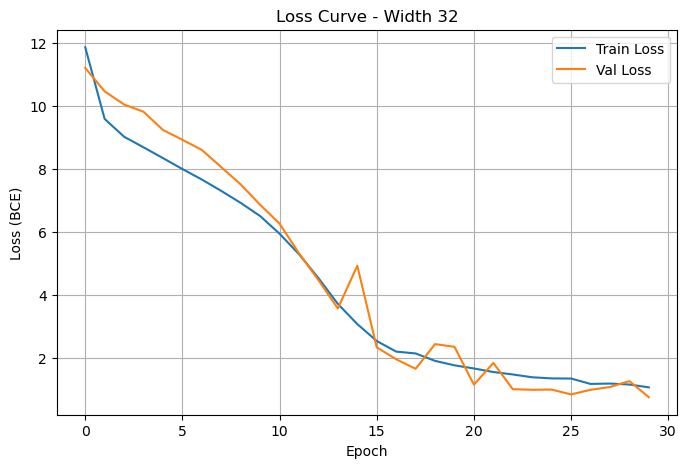


[Evaluasi Validation] Model Width 32:
Accuracy: 0.6696
                precision    recall  f1-score   support

Not Placed (0)       0.56      0.72      0.63       594
    Placed (1)       0.78      0.64      0.70       907

      accuracy                           0.67      1501
     macro avg       0.67      0.68      0.67      1501
  weighted avg       0.69      0.67      0.67      1501


[Distribusi] Model Width 32 - Hidden Layer Terakhir


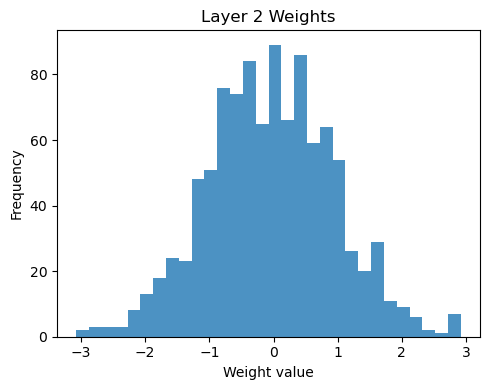

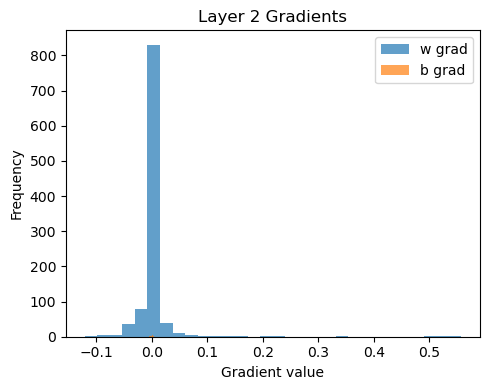

In [51]:
print(" EKSPERIMEN VARIASI WIDTH (DEPTH TETAP) ")

widths = [8, 16, 32]
models_width = {}

for w in widths:
    print(f"Training Model Width: {w} neurons")
    
    config = [nin, w, w, w, 1]
    acts = ['relu', 'relu', 'relu', 'sigmoid']
    
    model_w = FFNN(layers_config=config, activations=acts, loss_function='bce', random_state=RANDOM_STATE)
    history_w = model_w.fit(X_train, y_train, X_val, y_val, solver='sgd', lr=0.001, epochs=30, batch_size=32, verbose=1)
    
    models_width[w] = model_w
    plot_loss_curve(history_w, title=f"Loss Curve - Width {w}")
    print(f"\n[Evaluasi Validation] Model Width {w}:")
    evaluate_model(model_w, X_val, y_val)
    
    print(f"\n[Distribusi] Model Width {w} - Hidden Layer Terakhir")
    model_w.plot_weights_distribution(layer_indices=[2])
    model_w.plot_gradients_distribution(layer_indices=[2])

 EKSPERIMEN VARIASI DEPTH (WIDTH TETAP) 

Training Model Depth: 1 Hidden
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x0000023934D092D0>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934CA9B90>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x000002393A48FB10>
Epoch 1/30
219/219 [------------------------------] - loss: 3.2065 - val_loss: 2.5837
Epoch 2/30
219/219 [------------------------------] - loss: 2.4132 - val_loss: 2.1061
Epoch 3/30
219/219 [------------------------------] - loss: 2.0049 - val_loss: 1.8026
Epoch 4/30
219/219 [------------------------------] - loss: 1.7358 - val_loss: 1.6052
Epoch 5/30
219/219 [------------------------------] - loss: 1.5551 - val_loss: 1.4711
Epoch 6/30
219/219 [------------------------------] - loss: 1.4288 - val_loss: 1.3784
Epoch 7/30
219/219 [------------------------------] - loss: 1.3380 - val_loss: 1.3081
Epoch 8/30
219/219 [-----------------

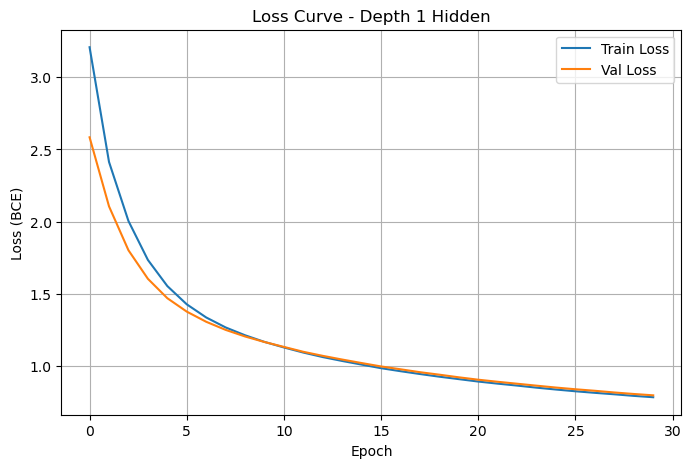


[Evaluasi Validation] Model Depth 1 Hidden:
Accuracy: 0.6795
                precision    recall  f1-score   support

Not Placed (0)       0.60      0.56      0.58       594
    Placed (1)       0.72      0.76      0.74       907

      accuracy                           0.68      1501
     macro avg       0.66      0.66      0.66      1501
  weighted avg       0.68      0.68      0.68      1501


[Distribusi] Model Depth 1 Hidden - Hidden Layer 1


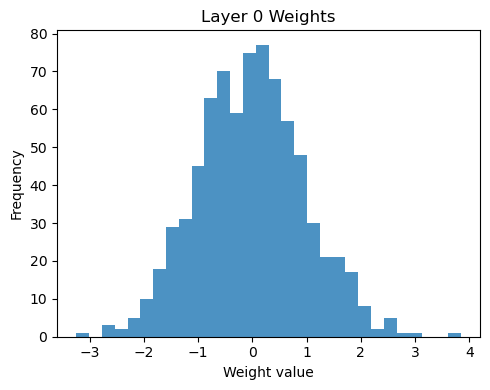

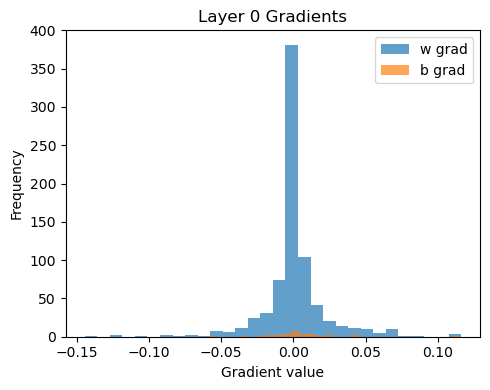


Training Model Depth: 2 Hidden
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x00000239352C3BD0>
activation name set relu
activation set <models.activations.ReLU object at 0x000002394A90DCD0>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934CC4DD0>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x0000023934E09050>
Epoch 1/30
219/219 [------------------------------] - loss: 7.3569 - val_loss: 5.7065
Epoch 2/30
219/219 [------------------------------] - loss: 4.6926 - val_loss: 4.4264
Epoch 3/30
219/219 [------------------------------] - loss: 3.7551 - val_loss: 3.7650
Epoch 4/30
219/219 [------------------------------] - loss: 3.2223 - val_loss: 3.2413
Epoch 5/30
219/219 [------------------------------] - loss: 2.8404 - val_loss: 2.9079
Epoch 6/30
219/219 [------------------------------] - loss: 2.5584 - val_loss: 2.6272
Epoch 7/30
219/219 [------------------------------] - loss: 2.3267 - 

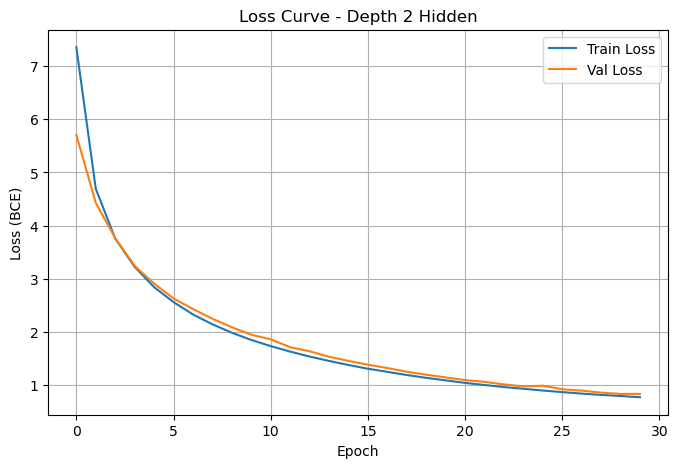


[Evaluasi Validation] Model Depth 2 Hidden:
Accuracy: 0.6875
                precision    recall  f1-score   support

Not Placed (0)       0.63      0.51      0.56       594
    Placed (1)       0.71      0.81      0.76       907

      accuracy                           0.69      1501
     macro avg       0.67      0.66      0.66      1501
  weighted avg       0.68      0.69      0.68      1501


[Distribusi] Model Depth 2 Hidden - Hidden Layer 1


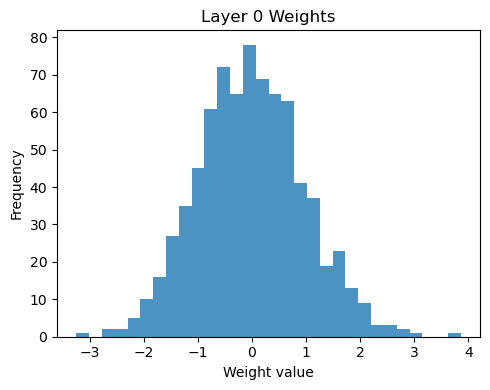

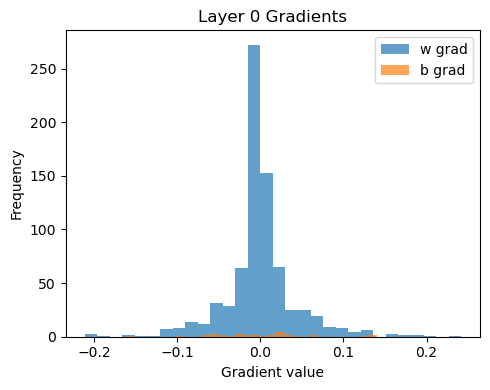


Training Model Depth: 3 Hidden
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x000002393A552790>
activation name set relu
activation set <models.activations.ReLU object at 0x000002393500F450>
activation name set relu
activation set <models.activations.ReLU object at 0x000002394A7E7810>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934E20F90>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x0000023935007B90>
Epoch 1/30
219/219 [------------------------------] - loss: 11.8721 - val_loss: 11.2139
Epoch 2/30
219/219 [------------------------------] - loss: 9.5940 - val_loss: 10.4691
Epoch 3/30
219/219 [------------------------------] - loss: 9.0281 - val_loss: 10.0521
Epoch 4/30
219/219 [------------------------------] - loss: 8.6917 - val_loss: 9.8219
Epoch 5/30
219/219 [------------------------------] - loss: 8.3496 - val_loss: 9.2429
Epoch 6/30
219/219 [------------------------------] - lo

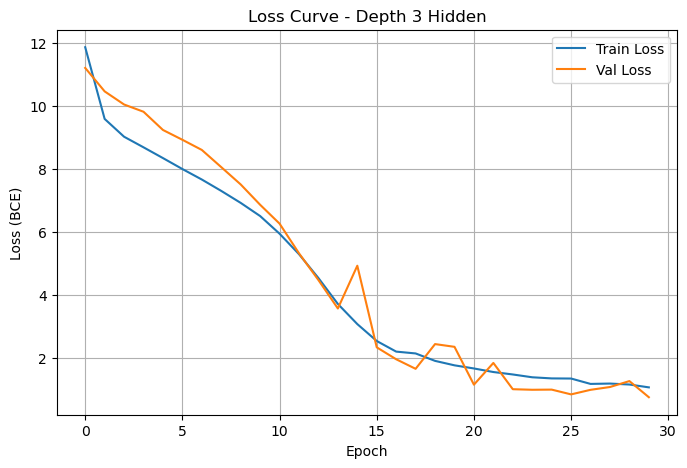


[Evaluasi Validation] Model Depth 3 Hidden:
Accuracy: 0.6696
                precision    recall  f1-score   support

Not Placed (0)       0.56      0.72      0.63       594
    Placed (1)       0.78      0.64      0.70       907

      accuracy                           0.67      1501
     macro avg       0.67      0.68      0.67      1501
  weighted avg       0.69      0.67      0.67      1501


[Distribusi] Model Depth 3 Hidden - Hidden Layer 1


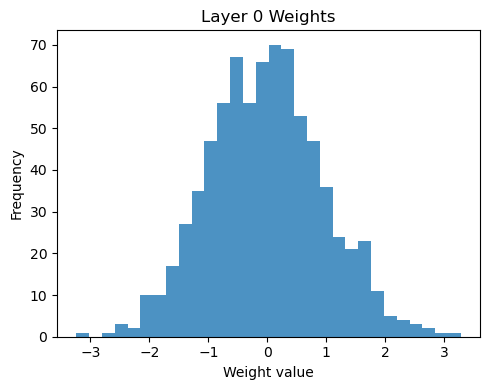

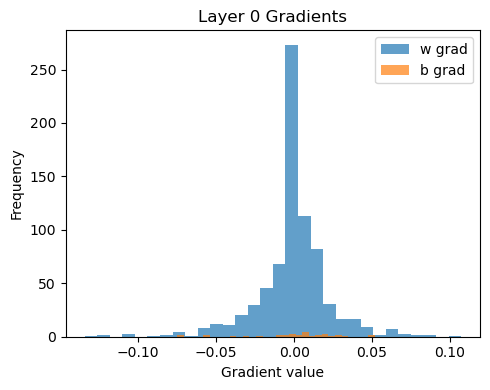

In [52]:
print(" EKSPERIMEN VARIASI DEPTH (WIDTH TETAP) ")

depths_configs = {
    "1 Hidden": ([nin, 32, 1], ['relu', 'sigmoid']),
    "2 Hidden": ([nin, 32, 32, 1], ['relu', 'relu', 'sigmoid']),
    "3 Hidden": ([nin, 32, 32, 32, 1], ['relu', 'relu', 'relu', 'sigmoid'])
}
models_depth = {}

for name, (config, acts) in depths_configs.items():
    print(f"\nTraining Model Depth: {name}")
    
    model_d = FFNN(layers_config=config, activations=acts, loss_function='bce', random_state=RANDOM_STATE)
    history_d = model_d.fit(X_train, y_train, X_val, y_val, solver='sgd', lr=0.001, epochs=30, batch_size=32, verbose=1)
    
    models_depth[name] = model_d
    plot_loss_curve(history_d, title=f"Loss Curve - Depth {name}")
    print(f"\n[Evaluasi Validation] Model Depth {name}:")
    evaluate_model(model_d, X_val, y_val)
    
    print(f"\n[Distribusi] Model Depth {name} - Hidden Layer 1")
    model_d.plot_weights_distribution(layer_indices=[0])
    model_d.plot_gradients_distribution(layer_indices=[0])

#### 3.1.2 Pengaruh fungsi aktivasi hidden layer.


Training Aktivasi Layer Uji: linear
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x000002393A51CD90>
activation name set relu
activation set <models.activations.ReLU object at 0x000002393A485750>
activation name set linear
activation set <models.activations.Linear object at 0x000002393A4D1450>
activation name set relu
activation set <models.activations.ReLU object at 0x000002393523FE50>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x0000023934CF7CD0>
Epoch 1/30
219/219 [------------------------------] - loss: 9.61151 - val_loss: 4.7817
Epoch 2/30
219/219 [------------------------------] - loss: 3.2440 - val_loss: 2.4762
Epoch 3/30
219/219 [------------------------------] - loss: 1.9270 - val_loss: 2.0987
Epoch 4/30
219/219 [------------------------------] - loss: 1.4520 - val_loss: 1.4186
Epoch 5/30
219/219 [------------------------------] - loss: 1.1970 - val_loss: 1.4402
Epoch 6/30
219/219 [------------------------------

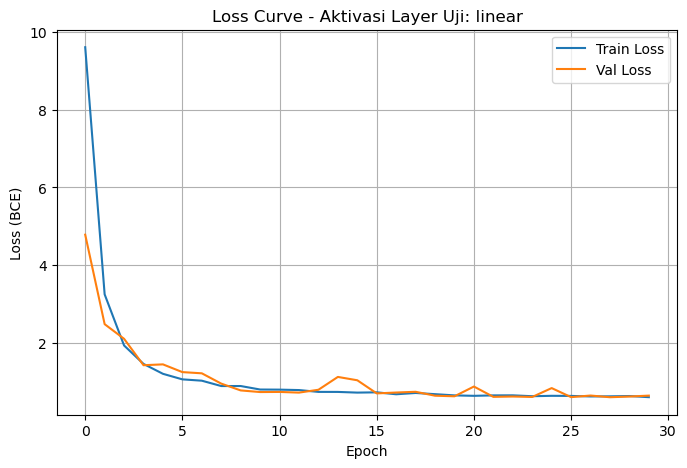


[Evaluasi Validation] Aktivasi linear:
Accuracy: 0.6696
                precision    recall  f1-score   support

Not Placed (0)       0.56      0.77      0.65       594
    Placed (1)       0.80      0.60      0.69       907

      accuracy                           0.67      1501
     macro avg       0.68      0.69      0.67      1501
  weighted avg       0.71      0.67      0.67      1501


[Distribusi] Aktivasi linear - Layer Uji


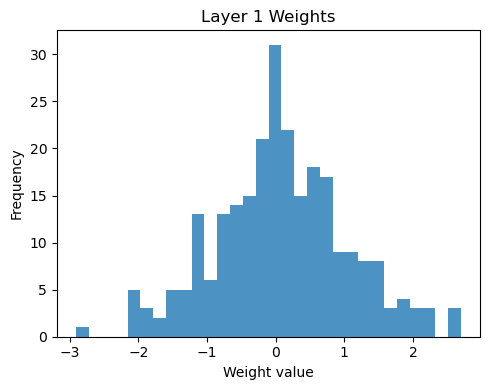

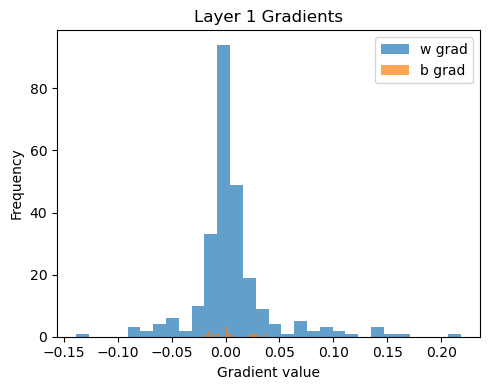


Training Aktivasi Layer Uji: relu
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x000002394A922110>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934E059D0>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023935E867D0>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934D43B90>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x0000023934CCDFD0>
Epoch 1/30
219/219 [------------------------------] - loss: 5.0833 - val_loss: 2.1727
Epoch 2/30
219/219 [------------------------------] - loss: 1.7756 - val_loss: 1.4008
Epoch 3/30
219/219 [------------------------------] - loss: 1.2324 - val_loss: 1.3882
Epoch 4/30
219/219 [------------------------------] - loss: 1.0412 - val_loss: 0.8826
Epoch 5/30
219/219 [------------------------------] - loss: 0.8922 - val_loss: 0.8922
Epoch 6/30
219/219 [------------------------------] - los

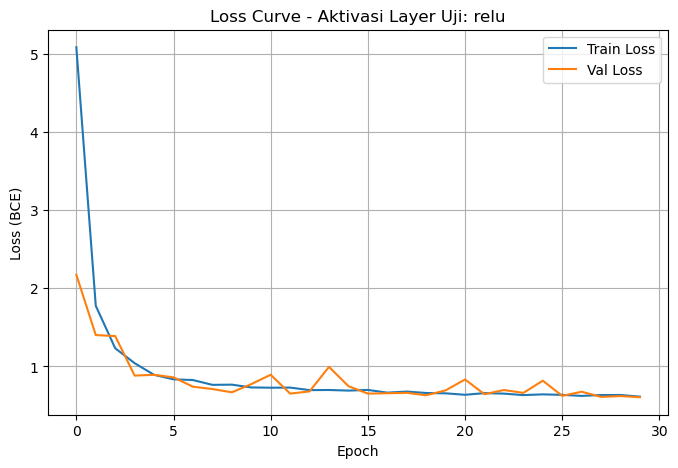


[Evaluasi Validation] Aktivasi relu:
Accuracy: 0.6676
                precision    recall  f1-score   support

Not Placed (0)       0.59      0.51      0.55       594
    Placed (1)       0.71      0.77      0.74       907

      accuracy                           0.67      1501
     macro avg       0.65      0.64      0.64      1501
  weighted avg       0.66      0.67      0.66      1501


[Distribusi] Aktivasi relu - Layer Uji


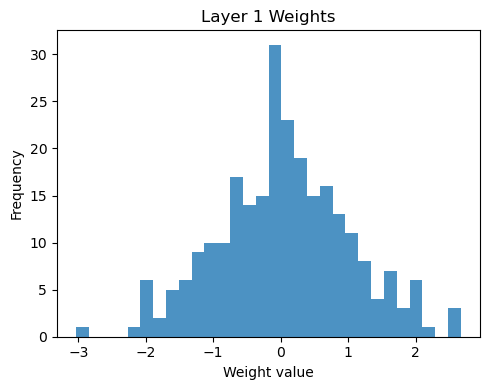

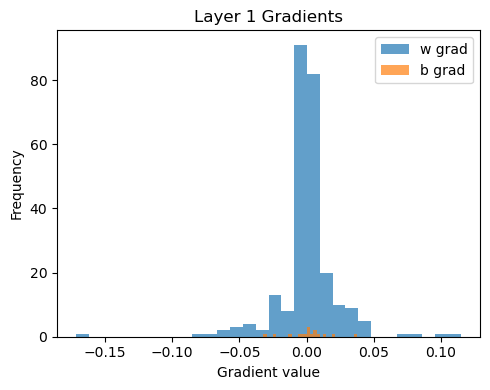


Training Aktivasi Layer Uji: sigmoid
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x000002396AB752D0>
activation name set relu
activation set <models.activations.ReLU object at 0x000002394A950C50>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x000002394A8085D0>
activation name set relu
activation set <models.activations.ReLU object at 0x00000239351178D0>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x000002396AD2E1D0>
Epoch 1/30
219/219 [------------------------------] - loss: 1.1714 - val_loss: 0.9287
Epoch 2/30
219/219 [------------------------------] - loss: 0.9045 - val_loss: 0.8577
Epoch 3/30
219/219 [------------------------------] - loss: 0.8412 - val_loss: 0.8115
Epoch 4/30
219/219 [------------------------------] - loss: 0.7975 - val_loss: 0.7787
Epoch 5/30
219/219 [------------------------------] - loss: 0.7655 - val_loss: 0.7545
Epoch 6/30
219/219 [----------------------------

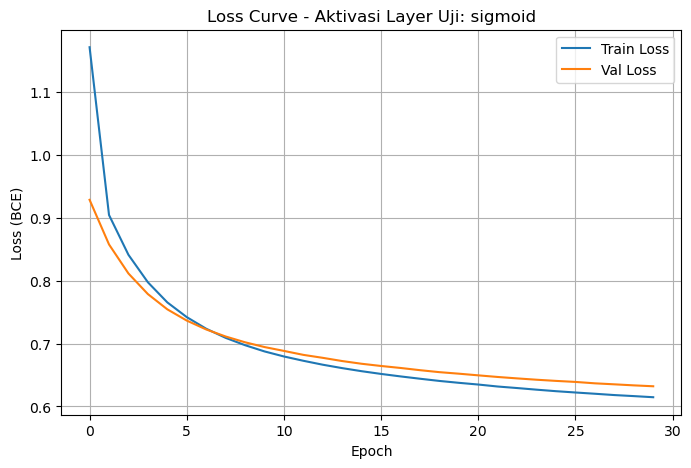


[Evaluasi Validation] Aktivasi sigmoid:
Accuracy: 0.6389
                precision    recall  f1-score   support

Not Placed (0)       0.57      0.38      0.45       594
    Placed (1)       0.67      0.81      0.73       907

      accuracy                           0.64      1501
     macro avg       0.62      0.59      0.59      1501
  weighted avg       0.63      0.64      0.62      1501


[Distribusi] Aktivasi sigmoid - Layer Uji


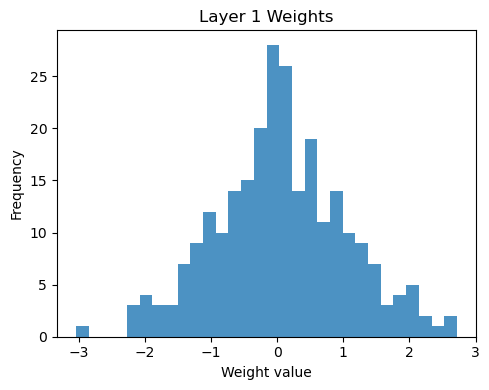

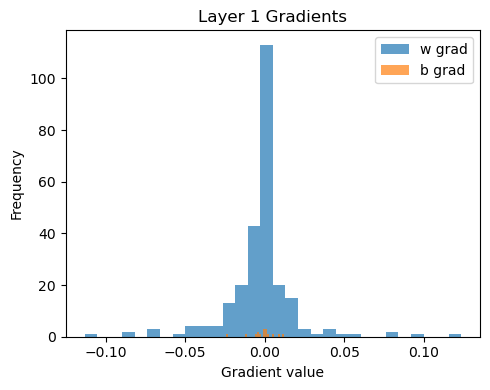


Training Aktivasi Layer Uji: tanh
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x0000023934133650>
activation name set relu
activation set <models.activations.ReLU object at 0x000002394A7F1450>
activation name set tanh
activation set <models.activations.TanH object at 0x000002394A943C90>
activation name set relu
activation set <models.activations.ReLU object at 0x000002396ACFCE10>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x0000023934F45DD0>
Epoch 1/30
219/219 [------------------------------] - loss: 2.7493 - val_loss: 1.5435
Epoch 2/30
219/219 [------------------------------] - loss: 1.4030 - val_loss: 1.2852
Epoch 3/30
219/219 [------------------------------] - loss: 1.2222 - val_loss: 1.1735
Epoch 4/30
219/219 [------------------------------] - loss: 1.1170 - val_loss: 1.0942
Epoch 5/30
219/219 [------------------------------] - loss: 1.0414 - val_loss: 1.0340
Epoch 6/30
219/219 [------------------------------] - los

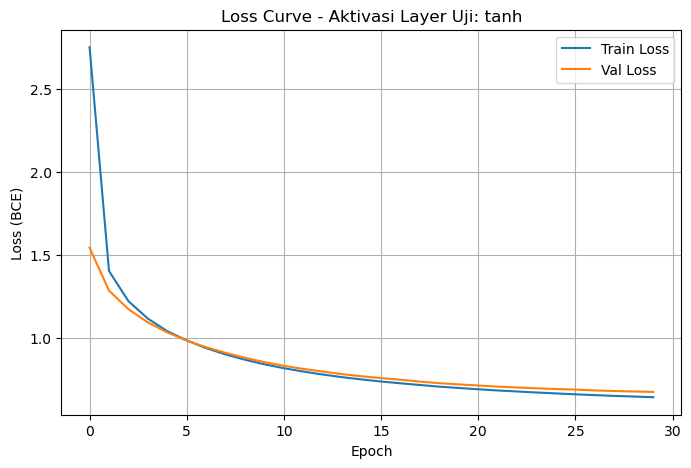


[Evaluasi Validation] Aktivasi tanh:
Accuracy: 0.6476
                precision    recall  f1-score   support

Not Placed (0)       0.57      0.43      0.49       594
    Placed (1)       0.68      0.79      0.73       907

      accuracy                           0.65      1501
     macro avg       0.63      0.61      0.61      1501
  weighted avg       0.64      0.65      0.64      1501


[Distribusi] Aktivasi tanh - Layer Uji


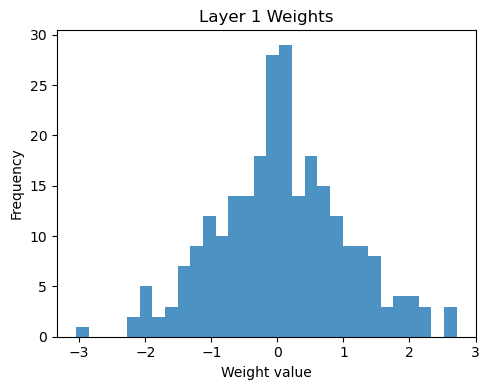

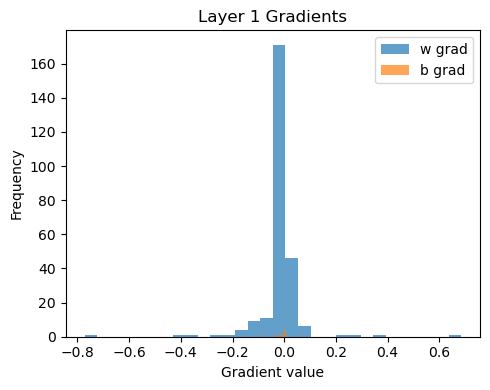

In [53]:
# Base arsitektur: Input -> Hidden1 -> Hidden2 (Layer Uji) -> Hidden3 -> Output
config_act = [nin, 16, 16, 16, 1]

activation_functions = ['linear', 'relu', 'sigmoid', 'tanh']
models_act = {}

for act in activation_functions:
    print(f"\nTraining Aktivasi Layer Uji: {act}")
    acts = ['relu', act, 'relu', 'sigmoid']
    
    model_a = FFNN(layers_config=config_act, activations=acts, loss_function='bce', random_state=RANDOM_STATE)
    history_a = model_a.fit(X_train, y_train, X_val, y_val, solver='sgd', lr=0.001, epochs=30, batch_size=32, verbose=1)
    
    models_act[act] = model_a
    plot_loss_curve(history_a, title=f"Loss Curve - Aktivasi Layer Uji: {act}")
    print(f"\n[Evaluasi Validation] Aktivasi {act}:")
    evaluate_model(model_a, X_val, y_val)
    
    print(f"\n[Distribusi] Aktivasi {act} - Layer Uji")
    model_a.plot_weights_distribution(layer_indices=[1])
    model_a.plot_gradients_distribution(layer_indices=[1])

#### 3.1.3 Pengaruh learning rate.


Training Model Learning Rate: 0.1
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x000002394A77C210>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023935E56ED0>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023935215B90>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x0000023934D55B10>
Epoch 1/30
219/219 [------------------------------] - loss: 3.4506 - val_loss: 0.7320
Epoch 2/30
219/219 [------------------------------] - loss: 0.6129 - val_loss: 0.6201
Epoch 3/30
219/219 [------------------------------] - loss: 0.5545 - val_loss: 0.6172
Epoch 4/30
219/219 [------------------------------] - loss: 0.5391 - val_loss: 0.5621
Epoch 5/30
219/219 [------------------------------] - loss: 0.5277 - val_loss: 0.5629
Epoch 6/30
219/219 [------------------------------] - loss: 0.5202 - val_loss: 0.5586
Epoch 7/30
219/219 [------------------------------] - loss: 0.5164

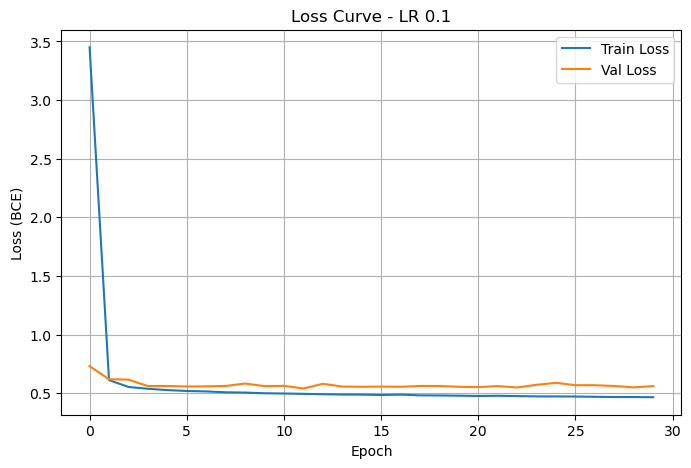


[Evaluasi Validation] LR 0.1:
Accuracy: 0.7182
                precision    recall  f1-score   support

Not Placed (0)       0.69      0.52      0.60       594
    Placed (1)       0.73      0.85      0.78       907

      accuracy                           0.72      1501
     macro avg       0.71      0.68      0.69      1501
  weighted avg       0.71      0.72      0.71      1501


[Distribusi Gradien] LR 0.1 - Semua Hidden Layer


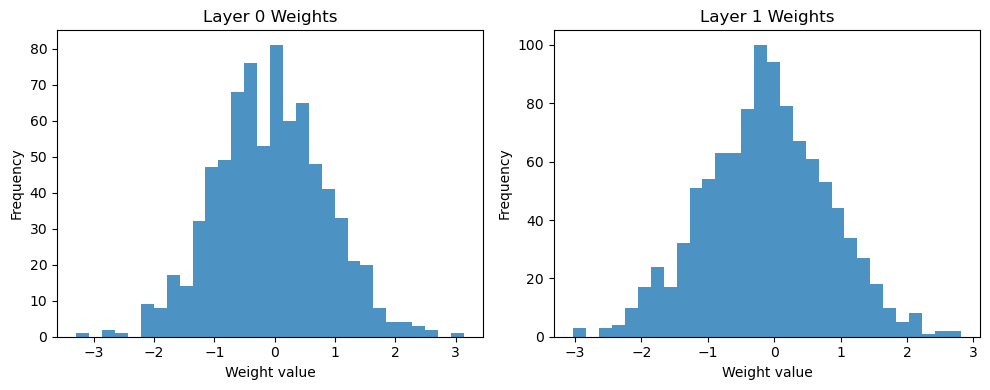

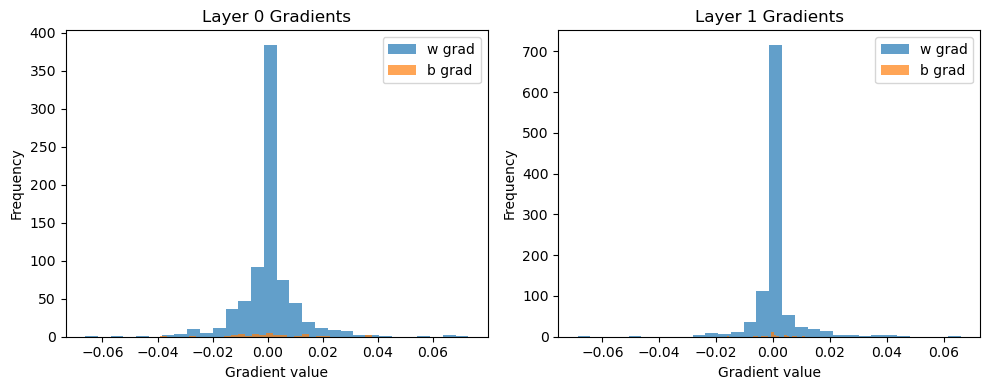


Training Model Learning Rate: 0.01
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x00000239352C9990>
activation name set relu
activation set <models.activations.ReLU object at 0x000002396AD2C2D0>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934FAD0D0>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x000002394A7F0050>
Epoch 1/30
219/219 [------------------------------] - loss: 3.6701 - val_loss: 2.2600
Epoch 2/30
219/219 [------------------------------] - loss: 1.6419 - val_loss: 1.5643
Epoch 3/30
219/219 [------------------------------] - loss: 1.1596 - val_loss: 1.2229
Epoch 4/30
219/219 [------------------------------] - loss: 0.9775 - val_loss: 0.8190
Epoch 5/30
219/219 [------------------------------] - loss: 0.8498 - val_loss: 0.6816
Epoch 6/30
219/219 [------------------------------] - loss: 0.7821 - val_loss: 1.2817
Epoch 7/30
219/219 [------------------------------] - loss: 0.721

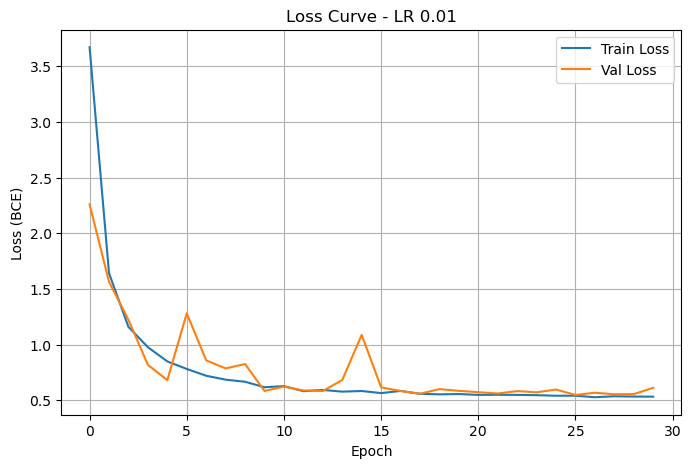


[Evaluasi Validation] LR 0.01:
Accuracy: 0.6935
                precision    recall  f1-score   support

Not Placed (0)       0.73      0.36      0.48       594
    Placed (1)       0.68      0.91      0.78       907

      accuracy                           0.69      1501
     macro avg       0.71      0.64      0.63      1501
  weighted avg       0.70      0.69      0.66      1501


[Distribusi Gradien] LR 0.01 - Semua Hidden Layer


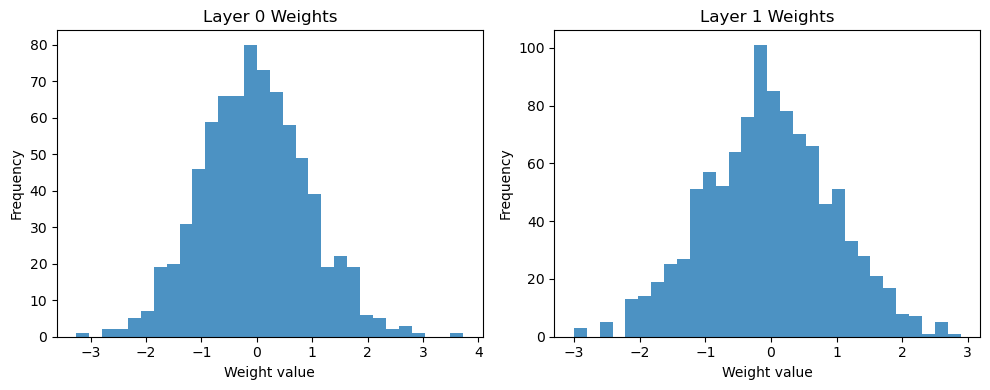

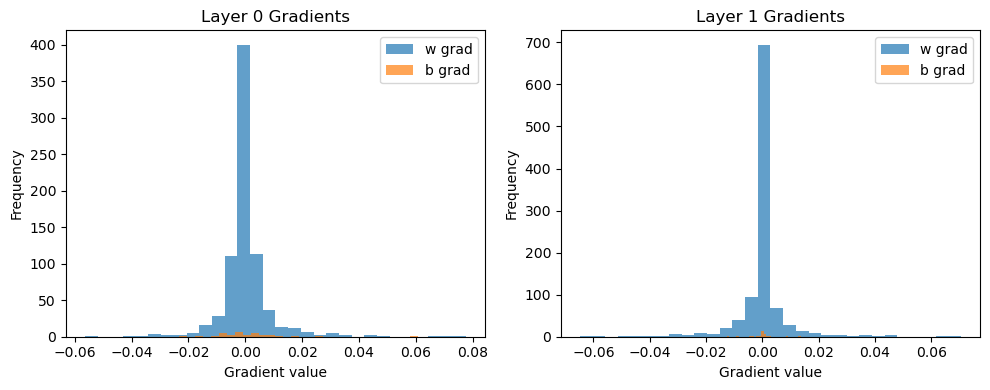


Training Model Learning Rate: 0.001
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x0000023934E22C10>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023935E565D0>
activation name set relu
activation set <models.activations.ReLU object at 0x000002396ABC08D0>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x0000023934E8A590>
Epoch 1/30
219/219 [------------------------------] - loss: 7.3569 - val_loss: 5.7065
Epoch 2/30
219/219 [------------------------------] - loss: 4.6926 - val_loss: 4.4264
Epoch 3/30
219/219 [------------------------------] - loss: 3.7551 - val_loss: 3.7650
Epoch 4/30
219/219 [------------------------------] - loss: 3.2223 - val_loss: 3.2413
Epoch 5/30
219/219 [------------------------------] - loss: 2.8404 - val_loss: 2.9079
Epoch 6/30
219/219 [------------------------------] - loss: 2.5584 - val_loss: 2.6272
Epoch 7/30
219/219 [------------------------------] - loss: 2.32

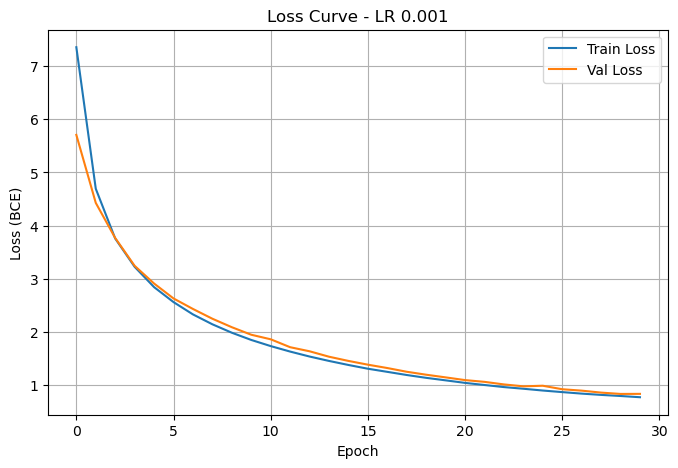


[Evaluasi Validation] LR 0.001:
Accuracy: 0.6875
                precision    recall  f1-score   support

Not Placed (0)       0.63      0.51      0.56       594
    Placed (1)       0.71      0.81      0.76       907

      accuracy                           0.69      1501
     macro avg       0.67      0.66      0.66      1501
  weighted avg       0.68      0.69      0.68      1501


[Distribusi Gradien] LR 0.001 - Semua Hidden Layer


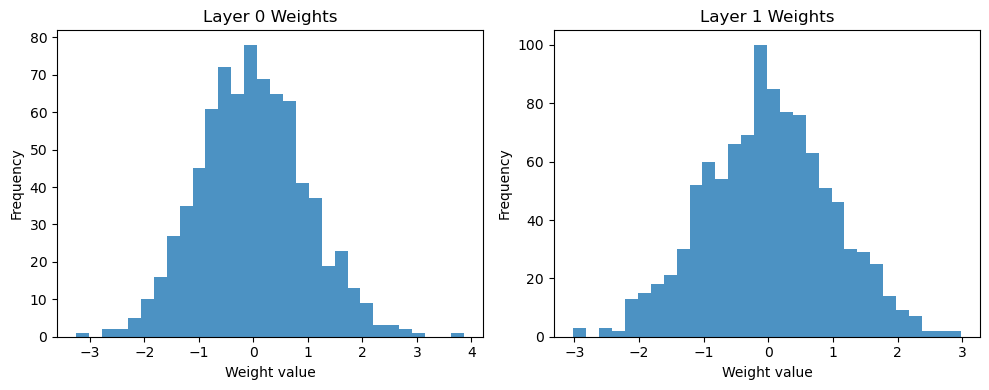

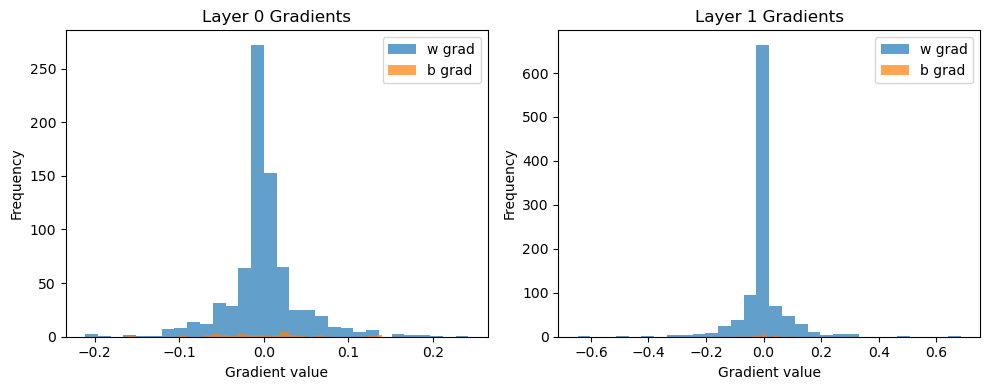

In [54]:
learning_rates = [0.1, 0.01, 0.001]
models_lr = {}

for lr in learning_rates:
    print(f"\nTraining Model Learning Rate: {lr}")
    config = [nin, 32, 32, 1]
    acts = ['relu', 'relu', 'sigmoid']
    
    model_lr = FFNN(layers_config=config, activations=acts, loss_function='bce', random_state=RANDOM_STATE)
    history_lr = model_lr.fit(X_train, y_train, X_val, y_val, solver='sgd', lr=lr, epochs=30, batch_size=32, verbose=1)
    
    models_lr[lr] = model_lr
    plot_loss_curve(history_lr, title=f"Loss Curve - LR {lr}")
    print(f"\n[Evaluasi Validation] LR {lr}:")
    evaluate_model(model_lr, X_val, y_val)
    
    print(f"\n[Distribusi Gradien] LR {lr} - Semua Hidden Layer")
    model_lr.plot_weights_distribution(layer_indices=[0, 1])
    model_lr.plot_gradients_distribution(layer_indices=[0, 1])

#### 3.1.4 Pengaruh Inisialisasi Bobot


Training Model Inisialisasi: zero
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x0000023935289C50>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023935095790>
activation name set relu
activation set <models.activations.ReLU object at 0x000002393A46BD90>
activation name set relu
activation set <models.activations.ReLU object at 0x000002393523D690>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x000002393A53DA90>
Epoch 1/30
219/219 [------------------------------] - loss: 0.6917 - val_loss: 0.6906
Epoch 2/30
219/219 [------------------------------] - loss: 0.6889 - val_loss: 0.6883
Epoch 3/30
219/219 [------------------------------] - loss: 0.6864 - val_loss: 0.6863
Epoch 4/30
219/219 [------------------------------] - loss: 0.6841 - val_loss: 0.6845
Epoch 5/30
219/219 [------------------------------] - loss: 0.6821 - val_loss: 0.6829
Epoch 6/30
219/219 [------------------------------] - los

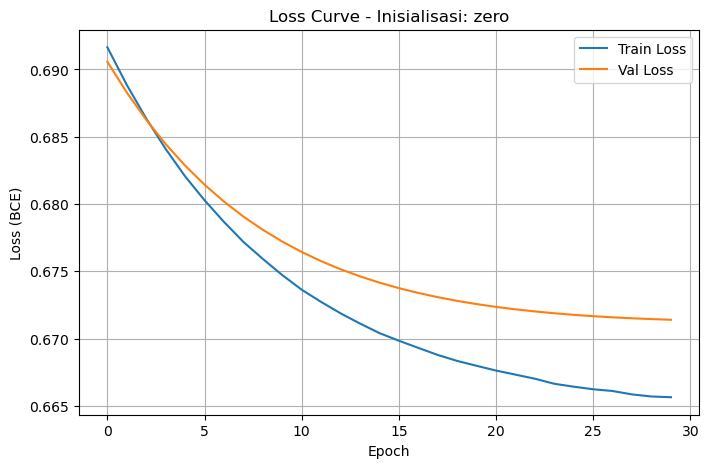


[Evaluasi Validation] Inisialisasi zero:
Accuracy: 0.6043
                precision    recall  f1-score   support

Not Placed (0)       0.00      0.00      0.00       594
    Placed (1)       0.60      1.00      0.75       907

      accuracy                           0.60      1501
     macro avg       0.30      0.50      0.38      1501
  weighted avg       0.37      0.60      0.46      1501


[Distribusi Bobot & Gradien] Inisialisasi zero - Layer 0 dan Layer 2


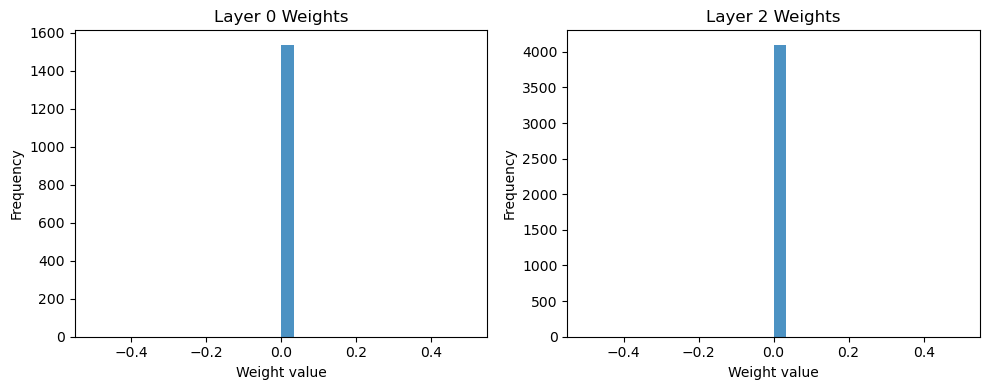

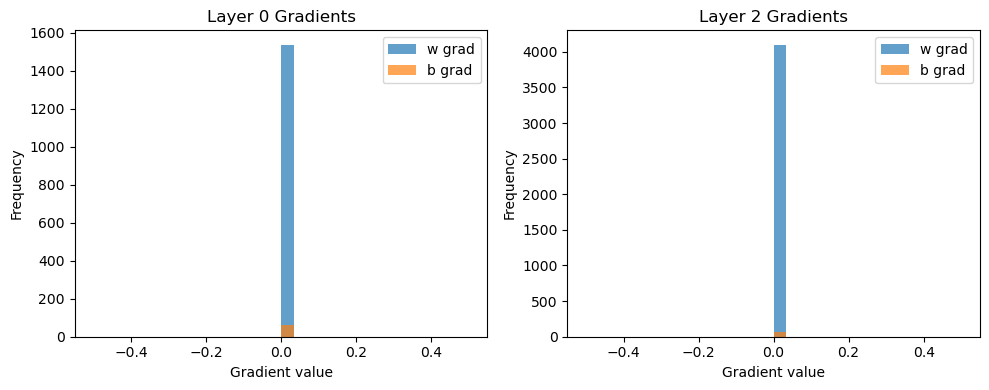


Training Model Inisialisasi: uniform
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x000002394A938610>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934D11550>
activation name set relu
activation set <models.activations.ReLU object at 0x00000239351B6250>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934C6EC10>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x000002393A4871D0>
Epoch 1/30
219/219 [------------------------------] - loss: 0.6923 - val_loss: 0.6909
Epoch 2/30
219/219 [------------------------------] - loss: 0.6891 - val_loss: 0.6883
Epoch 3/30
219/219 [------------------------------] - loss: 0.6862 - val_loss: 0.6859
Epoch 4/30
219/219 [------------------------------] - loss: 0.6836 - val_loss: 0.6839
Epoch 5/30
219/219 [------------------------------] - loss: 0.6814 - val_loss: 0.6821
Epoch 6/30
219/219 [------------------------------] - 

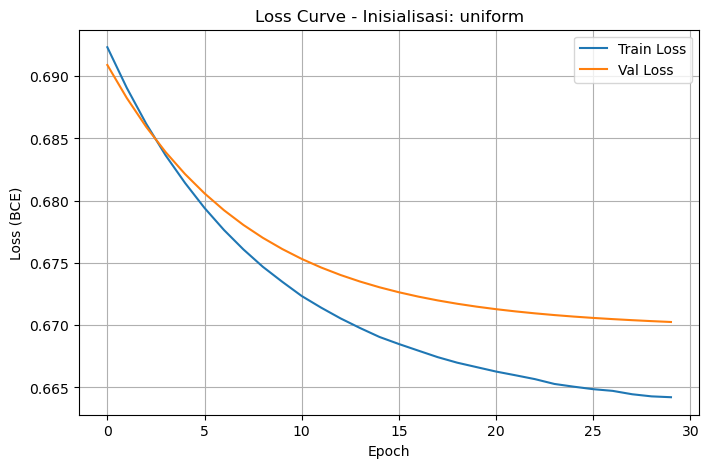


[Evaluasi Validation] Inisialisasi uniform:
Accuracy: 0.6043
                precision    recall  f1-score   support

Not Placed (0)       0.00      0.00      0.00       594
    Placed (1)       0.60      1.00      0.75       907

      accuracy                           0.60      1501
     macro avg       0.30      0.50      0.38      1501
  weighted avg       0.37      0.60      0.46      1501


[Distribusi Bobot & Gradien] Inisialisasi uniform - Layer 0 dan Layer 2


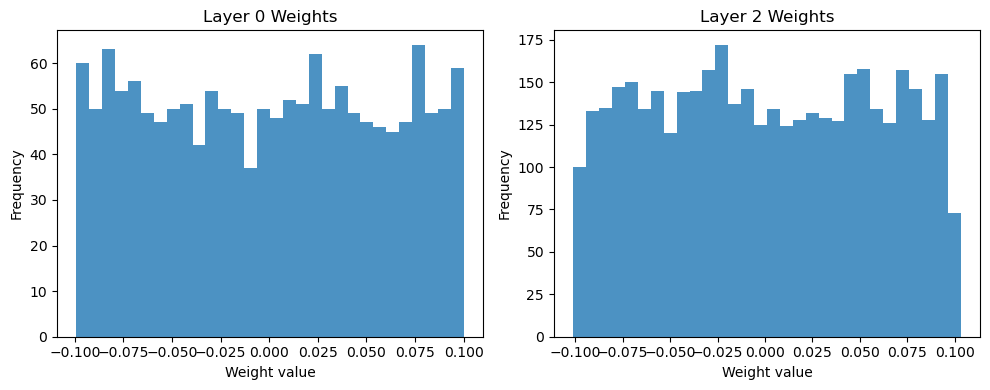

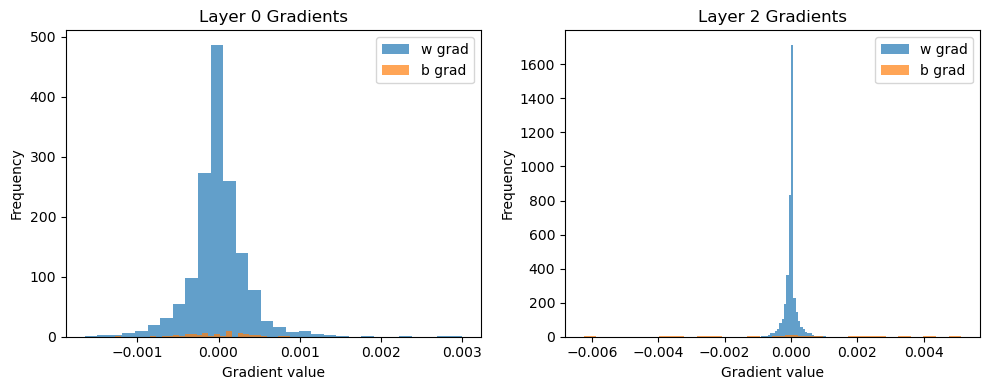


Training Model Inisialisasi: normal
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x000002393517A4D0>
activation name set relu
activation set <models.activations.ReLU object at 0x00000239351D5210>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934E237D0>
activation name set relu
activation set <models.activations.ReLU object at 0x00000239350F93D0>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x00000239350FADD0>
Epoch 1/30
13/219 [->............................] - loss: 21.9188

c:\Users\Kinan\Documents\Kinan-Docs\Kuliah\Jurusan\semester6\ML\tubes1\Tubes1-ML-FFNN-G60\src\models\activations.py:40: RuntimeWarning: overflow encountered in exp
  sig = np.where(x.data >= 0, 1 / (1 + np.exp(-x.data)), np.exp(x.data)/ (1 + np.exp(x.data)))


219/219 [------------------------------] - loss: 20.9386 - val_loss: 19.7608
Epoch 2/30
55/219 [------->......................] - loss: 19.0674

c:\Users\Kinan\Documents\Kinan-Docs\Kuliah\Jurusan\semester6\ML\tubes1\Tubes1-ML-FFNN-G60\src\models\activations.py:40: RuntimeWarning: invalid value encountered in divide
  sig = np.where(x.data >= 0, 1 / (1 + np.exp(-x.data)), np.exp(x.data)/ (1 + np.exp(x.data)))


219/219 [------------------------------] - loss: 14.4407 - val_loss: 11.5903
Epoch 3/30
219/219 [------------------------------] - loss: 10.7037 - val_loss: 10.6520
Epoch 4/30
219/219 [------------------------------] - loss: 9.89254 - val_loss: 9.9598
Epoch 5/30
219/219 [------------------------------] - loss: 9.2686 - val_loss: 10.0548
Epoch 6/30
219/219 [------------------------------] - loss: 9.0718 - val_loss: 9.9455
Epoch 7/30
219/219 [------------------------------] - loss: 8.9962 - val_loss: 9.8782
Epoch 8/30
219/219 [------------------------------] - loss: 8.8154 - val_loss: 9.7674
Epoch 9/30
219/219 [------------------------------] - loss: 8.7517 - val_loss: 9.8047
Epoch 10/30
219/219 [------------------------------] - loss: 8.7328 - val_loss: 9.5089
Epoch 11/30
219/219 [------------------------------] - loss: 8.6645 - val_loss: 9.6709
Epoch 12/30
219/219 [------------------------------] - loss: 8.6219 - val_loss: 9.4923
Epoch 13/30
219/219 [------------------------------] - l

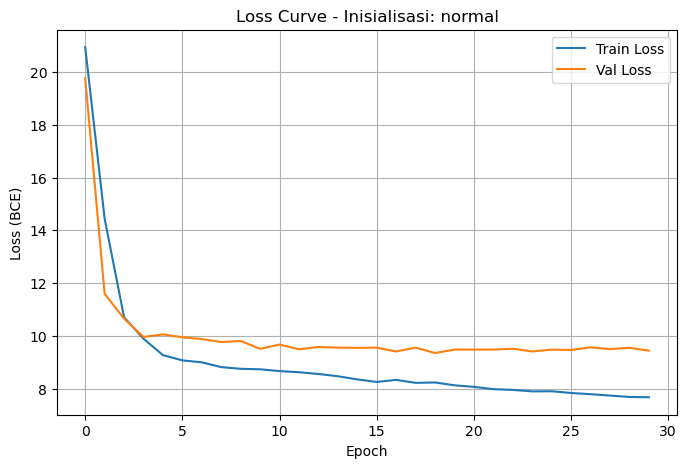


[Evaluasi Validation] Inisialisasi normal:
Accuracy: 0.7189
                precision    recall  f1-score   support

Not Placed (0)       0.67      0.56      0.61       594
    Placed (1)       0.74      0.82      0.78       907

      accuracy                           0.72      1501
     macro avg       0.71      0.69      0.70      1501
  weighted avg       0.71      0.72      0.71      1501


[Distribusi Bobot & Gradien] Inisialisasi normal - Layer 0 dan Layer 2


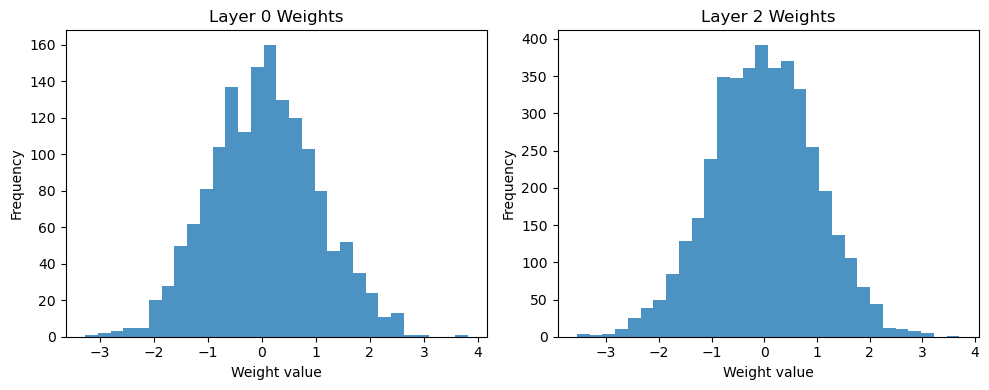

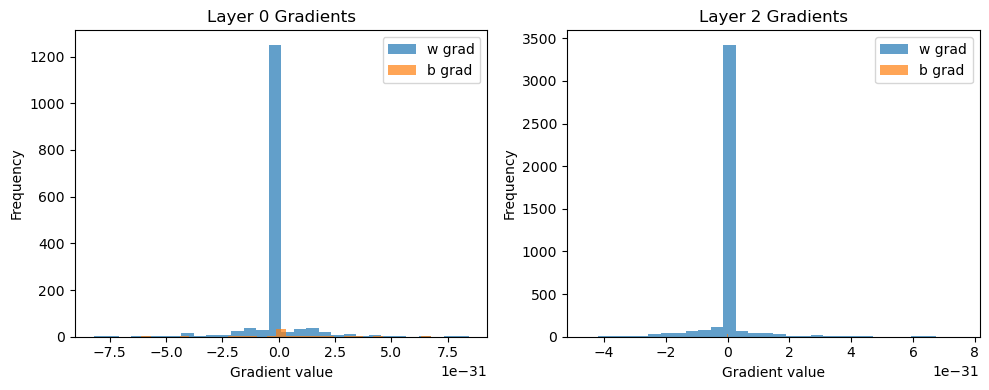


Training Model Inisialisasi: xavier
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x000002393F4D4390>
activation name set relu
activation set <models.activations.ReLU object at 0x00000239351B6290>
activation name set relu
activation set <models.activations.ReLU object at 0x00000239352C1B10>
activation name set relu
activation set <models.activations.ReLU object at 0x000002394A971910>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x0000023934EFDCD0>
Epoch 1/30
219/219 [------------------------------] - loss: 0.7180 - val_loss: 0.6956
Epoch 2/30
219/219 [------------------------------] - loss: 0.6793 - val_loss: 0.6697
Epoch 3/30
219/219 [------------------------------] - loss: 0.6554 - val_loss: 0.6532
Epoch 4/30
219/219 [------------------------------] - loss: 0.6390 - val_loss: 0.6417
Epoch 5/30
219/219 [------------------------------] - loss: 0.6266 - val_loss: 0.6327
Epoch 6/30
219/219 [------------------------------] - l

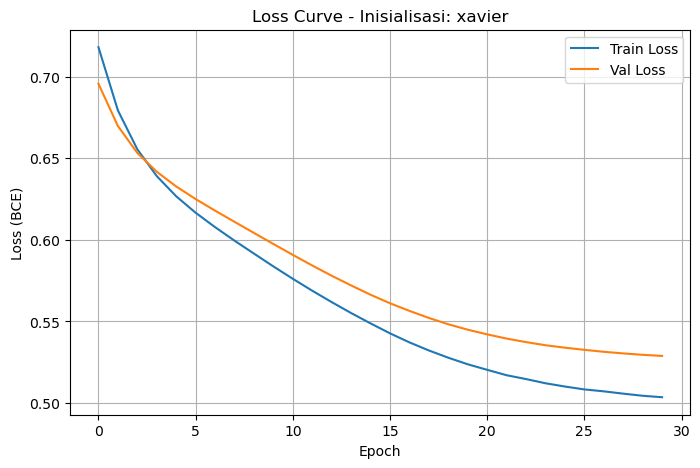


[Evaluasi Validation] Inisialisasi xavier:
Accuracy: 0.7368
                precision    recall  f1-score   support

Not Placed (0)       0.71      0.57      0.63       594
    Placed (1)       0.75      0.85      0.80       907

      accuracy                           0.74      1501
     macro avg       0.73      0.71      0.71      1501
  weighted avg       0.73      0.74      0.73      1501


[Distribusi Bobot & Gradien] Inisialisasi xavier - Layer 0 dan Layer 2


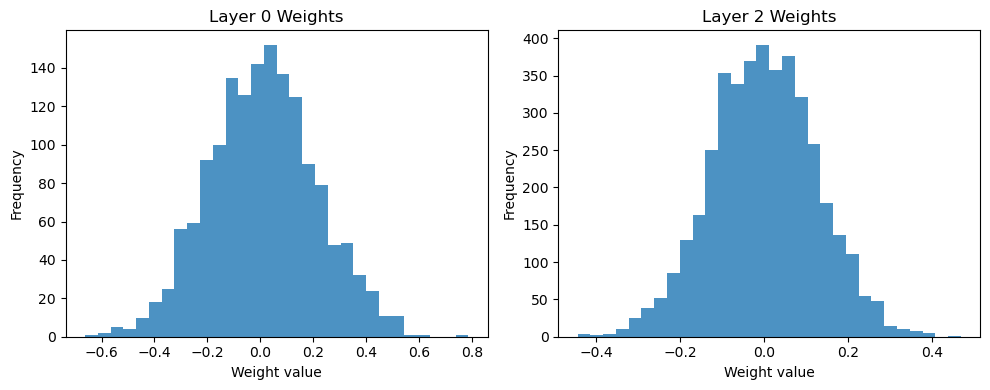

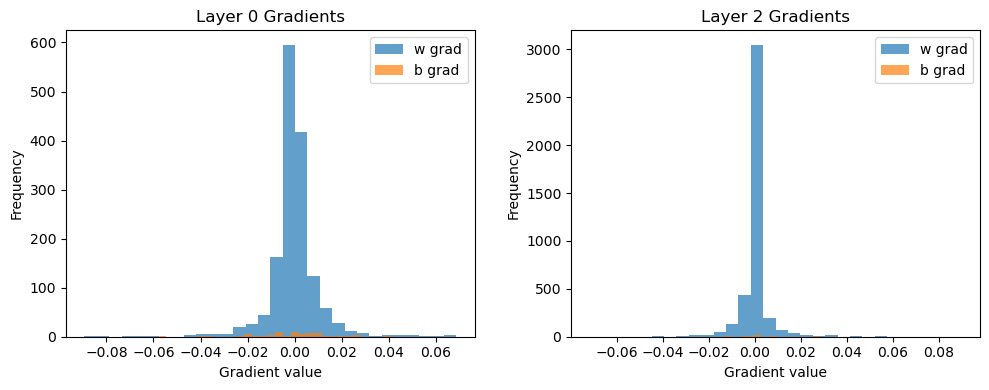


Training Model Inisialisasi: he
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x0000023935E91990>
activation name set relu
activation set <models.activations.ReLU object at 0x000002396AB506D0>
activation name set relu
activation set <models.activations.ReLU object at 0x000002393A51EA90>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934F64050>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x000002393513AA90>
Epoch 1/30
219/219 [------------------------------] - loss: 0.7551 - val_loss: 0.6437
Epoch 2/30
219/219 [------------------------------] - loss: 0.6047 - val_loss: 0.6089
Epoch 3/30
219/219 [------------------------------] - loss: 0.5752 - val_loss: 0.5908
Epoch 4/30
219/219 [------------------------------] - loss: 0.5575 - val_loss: 0.5781
Epoch 5/30
219/219 [------------------------------] - loss: 0.5453 - val_loss: 0.5691
Epoch 6/30
219/219 [------------------------------] - loss:

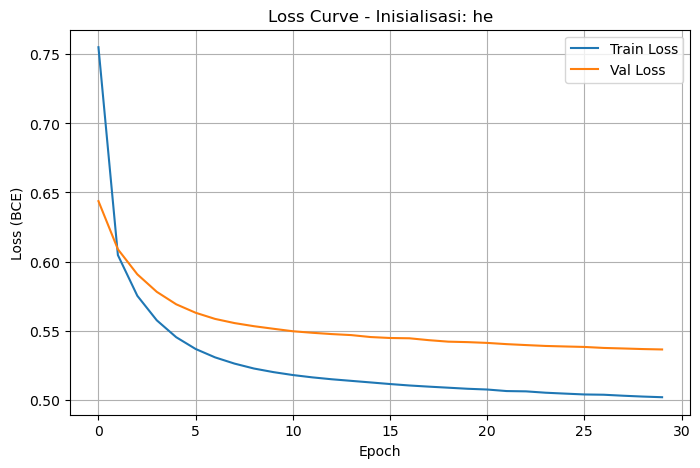


[Evaluasi Validation] Inisialisasi he:
Accuracy: 0.7255
                precision    recall  f1-score   support

Not Placed (0)       0.69      0.56      0.62       594
    Placed (1)       0.74      0.83      0.79       907

      accuracy                           0.73      1501
     macro avg       0.72      0.70      0.70      1501
  weighted avg       0.72      0.73      0.72      1501


[Distribusi Bobot & Gradien] Inisialisasi he - Layer 0 dan Layer 2


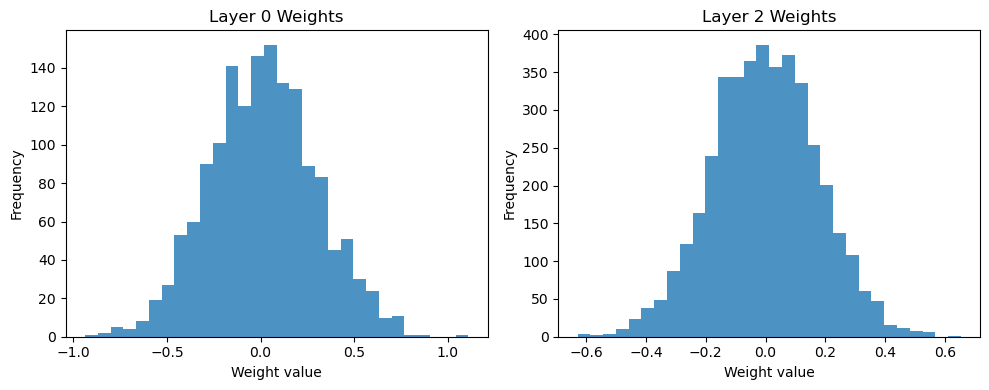

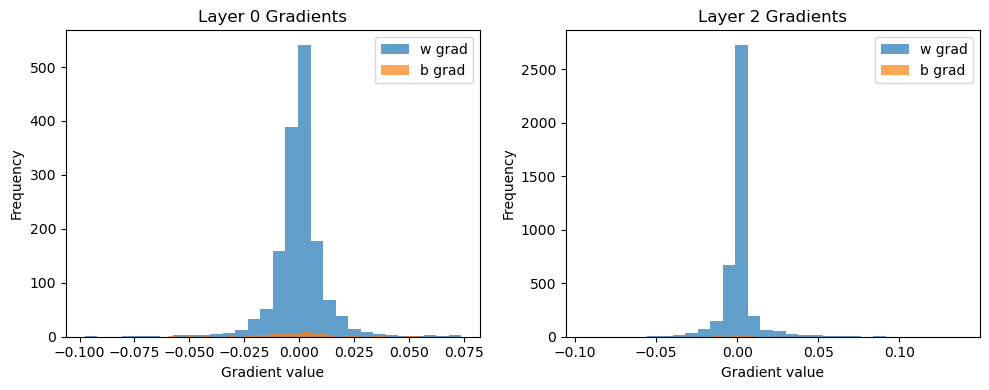

In [55]:
init_methods = ['zero', 'uniform', 'normal', 'xavier', 'he']
models_init = {}

config_init = [nin, 64, 64, 64, 1]
acts_init = ['relu', 'relu', 'relu', 'sigmoid']

for init_m in init_methods:
    print(f"\nTraining Model Inisialisasi: {init_m}")
    
    model_i = FFNN(layers_config=config_init, activations=acts_init, loss_function='bce', init_method=init_m, random_state=RANDOM_STATE)
    
    history_i = model_i.fit(X_train, y_train, X_val, y_val, solver='sgd', lr=0.001, epochs=30, batch_size=32, verbose=1)
    
    models_init[init_m] = model_i
    
    plot_loss_curve(history_i, title=f"Loss Curve - Inisialisasi: {init_m}")
    
    print(f"\n[Evaluasi Validation] Inisialisasi {init_m}:")
    evaluate_model(model_i, X_val, y_val)
    
    print(f"\n[Distribusi Bobot & Gradien] Inisialisasi {init_m} - Layer 0 dan Layer 2")
    model_i.plot_weights_distribution(layer_indices=[0, 2])
    model_i.plot_gradients_distribution(layer_indices=[0, 2])

### 3.2 Pengaruh Regularisasi.



Training Model: Tanpa Regularisasi
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x00000239351994D0>
activation name set relu
activation set <models.activations.ReLU object at 0x000002393F4DDA90>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023935E79F10>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x0000023935F0A610>
Epoch 1/30
1/219 [>.............................] - loss: 14.3618

219/219 [------------------------------] - loss: 7.8337 - val_loss: 6.4192
Epoch 2/30
219/219 [------------------------------] - loss: 5.4049 - val_loss: 5.6733
Epoch 3/30
219/219 [------------------------------] - loss: 3.6984 - val_loss: 2.8773
Epoch 4/30
219/219 [------------------------------] - loss: 2.8377 - val_loss: 3.5560
Epoch 5/30
219/219 [------------------------------] - loss: 2.1430 - val_loss: 2.8315
Epoch 6/30
219/219 [------------------------------] - loss: 1.7468 - val_loss: 3.9115
Epoch 7/30
219/219 [------------------------------] - loss: 1.3982 - val_loss: 3.9878
Epoch 8/30
219/219 [------------------------------] - loss: 1.2833 - val_loss: 1.1819
Epoch 9/30
219/219 [------------------------------] - loss: 1.1090 - val_loss: 1.8479
Epoch 10/30
219/219 [------------------------------] - loss: 1.0842 - val_loss: 1.1794
Epoch 11/30
219/219 [------------------------------] - loss: 0.9280 - val_loss: 0.7991
Epoch 12/30
219/219 [------------------------------] - loss: 0.

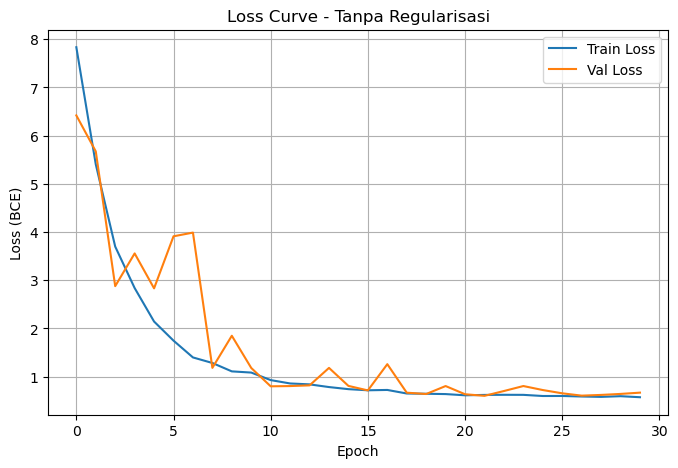


[Evaluasi Validation] Tanpa Regularisasi:
Accuracy: 0.7009
                precision    recall  f1-score   support

Not Placed (0)       0.70      0.42      0.53       594
    Placed (1)       0.70      0.88      0.78       907

      accuracy                           0.70      1501
     macro avg       0.70      0.65      0.65      1501
  weighted avg       0.70      0.70      0.68      1501


[Distribusi Bobot & Gradien] Tanpa Regularisasi


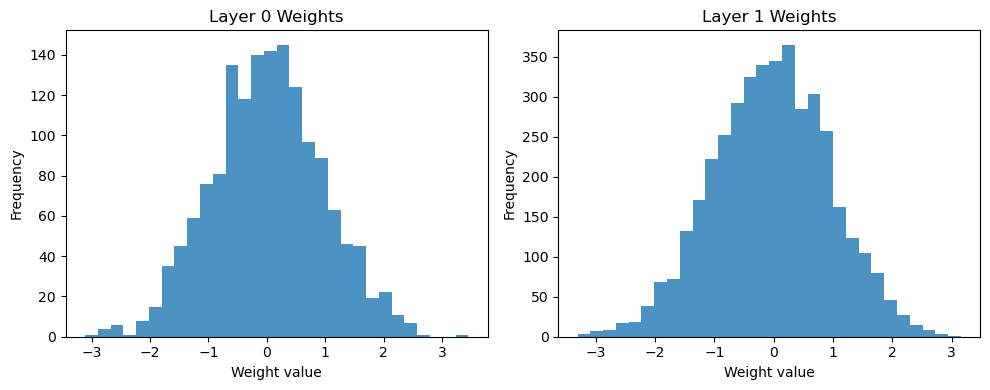

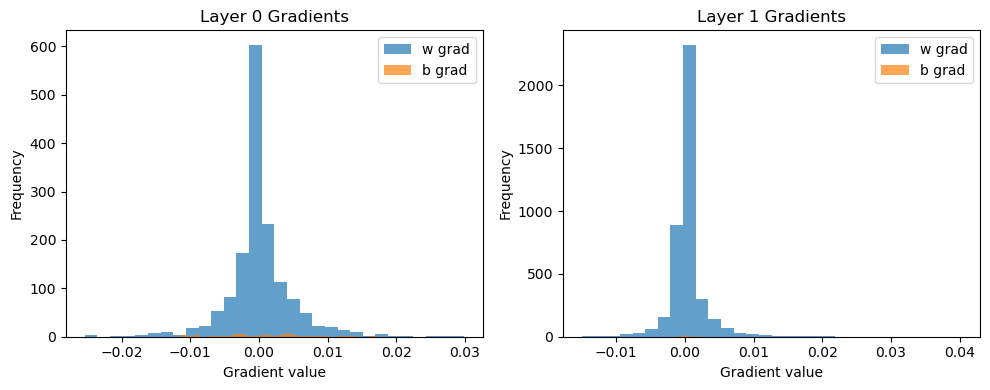


Training Model: L1 Regularization
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x000002393A4BC810>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934F596D0>
activation name set relu
activation set <models.activations.ReLU object at 0x00000239352A7E90>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x000002393517BBD0>
Epoch 1/30
219/219 [------------------------------] - loss: 12.3681 - val_loss: 10.8117
Epoch 2/30
219/219 [------------------------------] - loss: 9.94732 - val_loss: 10.1605
Epoch 3/30
219/219 [------------------------------] - loss: 8.2011 - val_loss: 7.3452
Epoch 4/30
219/219 [------------------------------] - loss: 7.2102 - val_loss: 7.7315
Epoch 5/30
219/219 [------------------------------] - loss: 6.5018 - val_loss: 7.0990
Epoch 6/30
219/219 [------------------------------] - loss: 6.0906 - val_loss: 7.9358
Epoch 7/30
219/219 [------------------------------] - loss: 5.

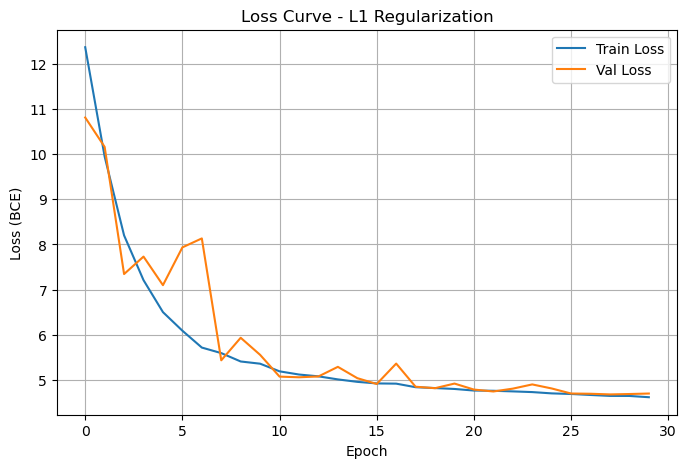


[Evaluasi Validation] L1 Regularization:
Accuracy: 0.7109
                precision    recall  f1-score   support

Not Placed (0)       0.71      0.45      0.55       594
    Placed (1)       0.71      0.88      0.79       907

      accuracy                           0.71      1501
     macro avg       0.71      0.67      0.67      1501
  weighted avg       0.71      0.71      0.69      1501


[Distribusi Bobot & Gradien] L1 Regularization


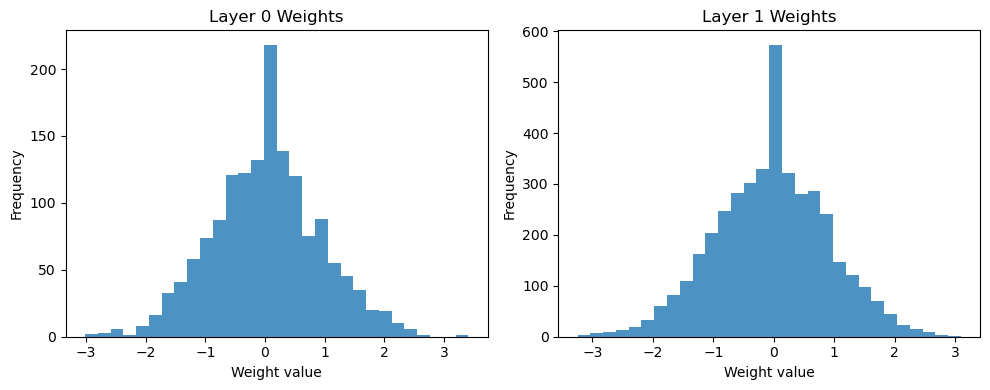

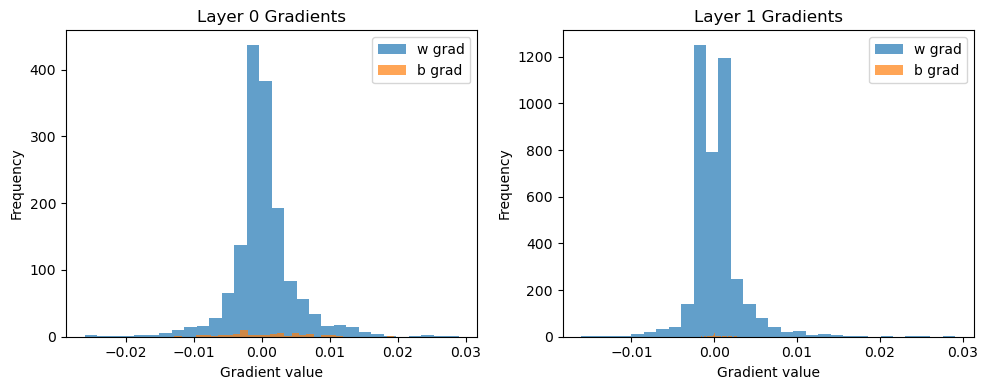


Training Model: L2 Regularization
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x000002393522EC10>
activation name set relu
activation set <models.activations.ReLU object at 0x000002394A872950>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934DD1B50>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x000002396AB44A90>
Epoch 1/30
219/219 [------------------------------] - loss: 13.4532 - val_loss: 11.9212
Epoch 2/30
219/219 [------------------------------] - loss: 10.9391 - val_loss: 11.0834
Epoch 3/30
219/219 [------------------------------] - loss: 9.0635 - val_loss: 8.2276
Epoch 4/30
219/219 [------------------------------] - loss: 8.0574 - val_loss: 8.6459
Epoch 5/30
219/219 [------------------------------] - loss: 7.3075 - val_loss: 7.6814
Epoch 6/30
219/219 [------------------------------] - loss: 6.8489 - val_loss: 8.5330
Epoch 7/30
219/219 [------------------------------] - loss: 6.

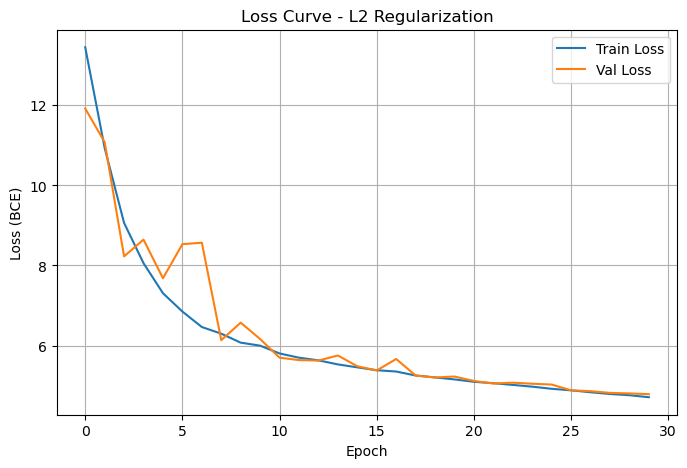


[Evaluasi Validation] L2 Regularization:
Accuracy: 0.7095
                precision    recall  f1-score   support

Not Placed (0)       0.72      0.43      0.54       594
    Placed (1)       0.71      0.89      0.79       907

      accuracy                           0.71      1501
     macro avg       0.71      0.66      0.66      1501
  weighted avg       0.71      0.71      0.69      1501


[Distribusi Bobot & Gradien] L2 Regularization


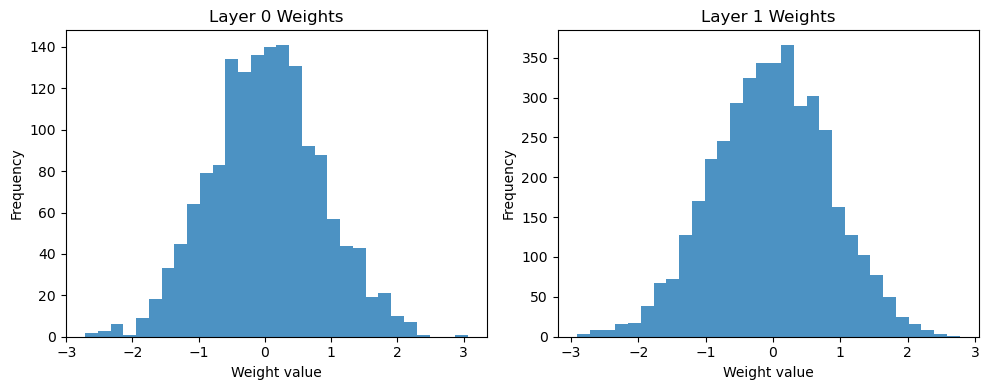

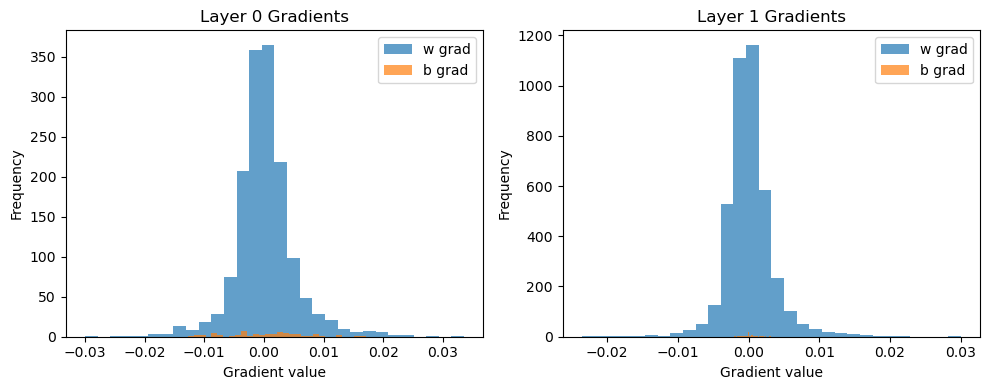

In [56]:
reg_variations = {
    "Tanpa Regularisasi": {"l1_lambda": 0.0, "l2_lambda": 0.0},
    "L1 Regularization": {"l1_lambda": 0.001, "l2_lambda": 0.0},
    "L2 Regularization": {"l1_lambda": 0.0, "l2_lambda": 0.001}
}
models_reg = {}

for name, params in reg_variations.items():
    print(f"\nTraining Model: {name}")
    config = [nin, 64, 64, 1] # 64 agar terlihat efek overfit/reg
    acts = ['relu', 'relu', 'sigmoid']
    
    model_r = FFNN(layers_config=config, activations=acts, loss_function='bce', random_state=RANDOM_STATE)
    history_r = model_r.fit(X_train, y_train, X_val, y_val, solver='sgd', lr=0.01, epochs=30, batch_size=32, l1_lambda=params["l1_lambda"], l2_lambda=params["l2_lambda"], verbose=1)
    
    models_reg[name] = model_r
    plot_loss_curve(history_r, title=f"Loss Curve - {name}")
    print(f"\n[Evaluasi Validation] {name}:")
    evaluate_model(model_r, X_val, y_val)
    
    print(f"\n[Distribusi Bobot & Gradien] {name}")
    model_r.plot_weights_distribution(layer_indices=[0, 1])
    model_r.plot_gradients_distribution(layer_indices=[0, 1])

### 3.3 Hyperparameter Tuning (Custom FFNN)

Strategi tuning menggunakan random search untuk mencari kombinasi arsitektur dan parameter training terbaik berdasarkan Macro F1-Score pada data validasi.

In [58]:
import os
import json
import time

# Diperkecil agar tuning lebih cepat dijalankan di notebook.
N_TRIALS = 10
TRAIN_SUBSET_FRACTION = 0.7

search_space = {
    'n_hidden': [1, 2, 3],
    'width': [16, 32, 64],
    'hidden_act': ['relu', 'tanh'],
    'lr': [0.0005, 0.001, 0.003, 0.01],
    'batch_size': [16, 32, 64],
    'init_method': ['uniform', 'normal', 'xavier', 'he'],
    'l1_lambda': [0.0, 1e-5, 1e-4],
    'l2_lambda': [0.0, 1e-5, 1e-4, 1e-3],
    'epochs': [15, 25, 35]
}

rng = np.random.default_rng(RANDOM_STATE)
results = []
best_score_so_far = -np.inf
best_params = None
best_model = None
history_best = None

n_trials = min(N_TRIALS, len(X_train))
sampled_idx = rng.choice(
    len(X_train),
    size=max(1, int(len(X_train) * TRAIN_SUBSET_FRACTION)),
    replace=False
)
X_train_tune = X_train[sampled_idx]
y_train_tune = y_train[sampled_idx]

start_time = time.time()

for trial_num in range(1, n_trials + 1):
    n_hidden = int(rng.choice(search_space['n_hidden']))
    width = int(rng.choice(search_space['width']))
    hidden_act = str(rng.choice(search_space['hidden_act']))
    lr_tune = float(rng.choice(search_space['lr']))
    batch_tune = int(rng.choice(search_space['batch_size']))
    init_m = str(rng.choice(search_space['init_method']))
    l1_tune = float(rng.choice(search_space['l1_lambda']))
    l2_tune = float(rng.choice(search_space['l2_lambda']))
    epochs_tune = int(rng.choice(search_space['epochs']))

    layers_cfg = [nin] + [width] * n_hidden + [1]
    acts_cfg = [hidden_act] * n_hidden + ['sigmoid']

    model_tune = FFNN(
        layers_config=layers_cfg,
        activations=acts_cfg,
        loss_function='bce',
        init_method=init_m,
        random_state=RANDOM_STATE + trial_num
    )

    history_tune = model_tune.fit(
        X_train_tune, y_train_tune, X_val, y_val,
        solver='sgd',
        lr=lr_tune,
        batch_size=batch_tune,
        epochs=epochs_tune,
        l1_lambda=l1_tune,
        l2_lambda=l2_tune,
        verbose=0
    )

    val_probs = model_tune.predict(X_val)
    val_preds = (val_probs >= 0.5).astype(int).ravel()
    val_true = y_val.ravel().astype(int)

    val_macro_f1 = f1_score(val_true, val_preds, average='macro', zero_division=0)
    val_accuracy = (val_preds == val_true).mean()
    final_train_loss = history_tune['train_loss'][-1]
    final_val_loss = history_tune['val_loss'][-1] if len(history_tune['val_loss']) > 0 else np.nan

    row = {
        'trial': trial_num,
        'layers_config': str(layers_cfg),
        'activations': str(acts_cfg),
        'init_method': init_m,
        'lr': lr_tune,
        'batch_size': batch_tune,
        'epochs': epochs_tune,
        'l1_lambda': l1_tune,
        'l2_lambda': l2_tune,
        'val_macro_f1': float(val_macro_f1),
        'val_accuracy': float(val_accuracy),
        'final_train_loss': float(final_train_loss),
        'final_val_loss': float(final_val_loss)
    }
    results.append(row)

    if val_macro_f1 > best_score_so_far:
        best_score_so_far = val_macro_f1
        best_params = {
            'layers_config': layers_cfg,
            'activations': acts_cfg,
            'init_method': init_m,
            'lr': lr_tune,
            'batch_size': batch_tune,
            'epochs': epochs_tune,
            'l1_lambda': l1_tune,
            'l2_lambda': l2_tune
        }
        best_model = model_tune
        history_best = history_tune

    print(
        f"Trial {trial_num:02d}/{n_trials} | "
        f"F1-macro={val_macro_f1:.4f} | "
        f"acc={val_accuracy:.4f} | "
        f"cfg={layers_cfg}, act={acts_cfg}, lr={lr_tune}, bs={batch_tune}, init={init_m}"
    )

elapsed = time.time() - start_time
results_df = pd.DataFrame(results).sort_values(
    by=['val_macro_f1', 'final_val_loss'],
    ascending=[False, True]
).reset_index(drop=True)

print(f"\nTuning selesai dalam {elapsed:.2f} detik")
print('Top 5 konfigurasi:')
display(results_df.head(5))

best_row = results_df.iloc[0]
print('\nBest trial (berdasarkan validasi):')
display(best_row.to_frame().T)

loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x0000023934D00A50>
activation name set tanh
activation set <models.activations.TanH object at 0x000002394A6D5490>
activation name set tanh
activation set <models.activations.TanH object at 0x0000023935114290>
activation name set tanh
activation set <models.activations.TanH object at 0x0000023935117490>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x0000023935117CD0>
Trial 01/10 | F1-macro=0.7162 | acc=0.7375 | cfg=[24, 64, 64, 64, 1], act=['tanh', 'tanh', 'tanh', 'sigmoid'], lr=0.003, bs=32, init=xavier
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x000002393F47A810>
activation name set relu
activation set <models.activations.ReLU object at 0x00000239351AEC90>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934175C10>
activation name set relu
activation set <models.activations.ReLU object at 0x0000023934175AD0>
activ

,trial,layers_config,activations,init_method,lr,batch_size,epochs,l1_lambda,l2_lambda,val_macro_f1,val_accuracy,final_train_loss,final_val_loss
0,8,"[24, 64, 64, 1]","['tanh', 'tanh', 'sigmoid']",he,0.003,32,25,0.0000,0.00001,0.723868,0.744171,0.486435,0.515722
1,10,"[24, 16, 16, 1]","['relu', 'relu', 'sigmoid']",uniform,0.010,32,25,0.0000,0.00010,0.719353,0.742172,0.498861,0.521305
2,9,"[24, 32, 32, 1]","['relu', 'relu', 'sigmoid']",he,0.010,32,25,0.0001,0.00100,0.717978,0.737508,0.618709,0.661146
3,1,"[24, 64, 64, 64, 1]","['tanh', 'tanh', 'tanh', 'sigmoid']",xavier,0.003,32,15,0.0000,0.00100,0.716233,0.737508,0.671847,0.698313
4,3,"[24, 16, 1]","['tanh', 'sigmoid']",he,0.001,16,25,0.0000,0.00000,0.709443,0.738175,0.506090,0.525360



Best trial (berdasarkan validasi):


,trial,layers_config,activations,init_method,lr,batch_size,epochs,l1_lambda,l2_lambda,val_macro_f1,val_accuracy,final_train_loss,final_val_loss
0,8,"[24, 64, 64, 1]","['tanh', 'tanh', 'sigmoid']",he,0.003,32,25,0.0,0.00001,0.723868,0.744171,0.486435,0.515722


In [59]:
print(best_params)

{'layers_config': [24, 64, 64, 1], 'activations': ['tanh', 'tanh', 'sigmoid'], 'init_method': 'he', 'lr': 0.003, 'batch_size': 32, 'epochs': 25, 'l1_lambda': 0.0, 'l2_lambda': 1e-05}


### 3.4 Uji Perbandingan.

In [62]:
print("\nUji Perbandingan: Custom FFNN (Best Tuning) vs Sklearn MLP")

if 'best_params' in globals() and best_params is not None:
    config_custom = best_params['layers_config']
    acts_custom = best_params['activations']
    init_custom = best_params['init_method']
    lr_custom = best_params['lr']
    batch_custom = best_params['batch_size']
    epochs_custom = best_params['epochs']
    l1_custom = best_params['l1_lambda']
    l2_custom = best_params['l2_lambda']
else:
    print('best_params tidak ditemukan. Menggunakan konfigurasi default.')
    config_custom = [nin, 32, 32, 1]
    acts_custom = ['relu', 'relu', 'sigmoid']
    init_custom = 'xavier'
    lr_custom = 0.01
    batch_custom = 32
    epochs_custom = 100
    l1_custom = 0.0
    l2_custom = 0.0

print("\n[Parameter Custom FFNN]")
print(f"Layers Config     : {config_custom}")
print(f"Activations       : {acts_custom}")
print(f"Initialization    : {init_custom}")
print(f"Learning Rate     : {lr_custom}")
print(f"Batch Size        : {batch_custom}")
print(f"Epochs            : {epochs_custom}")
print(f"L1 Lambda         : {l1_custom}")
print(f"L2 Lambda         : {l2_custom}")

print("\n[Parameter Sklearn MLPClassifier]")
print(f"Hidden Layers     : (64, 64)")
print(f"Activation        : tanh")
print(f"Solver            : sgd")
print(f"Learning Rate     : 0.003")
print(f"Batch Size        : 32")
print(f"Max Iter          : 25")
print(f"L2 Regularization : 1e-5")
print(f"Random State      : {RANDOM_STATE}")

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.vstack([y_train, y_val])

model_custom = FFNN(
    layers_config=config_custom,
    activations=acts_custom,
    loss_function='bce',
    init_method=init_custom,
    random_state=RANDOM_STATE
    )
model_custom.fit(
    X_trainval, y_trainval,
    solver='sgd',
    lr=lr_custom,
    epochs=epochs_custom,
    batch_size=batch_custom,
    l1_lambda=l1_custom,
    l2_lambda=l2_custom,
    verbose=0
    )

print("\n[Hasil Akhir] Custom FFNN (best tuning) di Data TEST:")
evaluate_model(model_custom, X_test, y_test)
preds_custom = (model_custom.predict(X_test) >= 0.5).astype(int).ravel()
print(f"Macro F1 (Custom): {f1_score(y_test.ravel(), preds_custom, average='macro', zero_division=0):.4f}")

model_sklearn = MLPClassifier(
    hidden_layer_sizes=(64, 64),
    activation='tanh',
    solver='sgd',
    learning_rate='constant',
    learning_rate_init=0.003,
    batch_size=32,
    max_iter=25,
    alpha=1e-5,
    shuffle=True,
    random_state=RANDOM_STATE
)

model_sklearn.fit(X_trainval, y_trainval.ravel())
preds_sklearn = model_sklearn.predict(X_test)

print("\n[Hasil Akhir] Sklearn MLPClassifier di Data TEST:")
print(f"Accuracy: {accuracy_score(y_test.ravel(), preds_sklearn):.4f}")
print(f"Macro F1 (Sklearn): {f1_score(y_test.ravel(), preds_sklearn, average='macro', zero_division=0):.4f}")
print(classification_report(
    y_test.ravel(),
    preds_sklearn,
    target_names=['Not Placed (0)', 'Placed (1)'],
    zero_division=0
))


Uji Perbandingan: Custom FFNN (Best Tuning) vs Sklearn MLP

[Parameter Custom FFNN]
Layers Config     : [24, 64, 64, 1]
Activations       : ['tanh', 'tanh', 'sigmoid']
Initialization    : he
Learning Rate     : 0.003
Batch Size        : 32
Epochs            : 25
L1 Lambda         : 0.0
L2 Lambda         : 1e-05

[Parameter Sklearn MLPClassifier]
Hidden Layers     : (64, 64)
Activation        : tanh
Solver            : sgd
Learning Rate     : 0.003
Batch Size        : 32
Max Iter          : 25
L2 Regularization : 1e-5
Random State      : 42
loss name set bce
loss fn set <models.loss.BinaryClassEntropy object at 0x0000023934AF4250>
activation name set tanh
activation set <models.activations.TanH object at 0x0000023934E9C390>
activation name set tanh
activation set <models.activations.TanH object at 0x0000023934AF5610>
activation name set sigmoid
activation set <models.activations.Sigmoid object at 0x0000023934AF7F50>

[Hasil Akhir] Custom FFNN (best tuning) di Data TEST:
Accuracy: 0.774

c:\Users\Kinan\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(


**Kesimpulan Perbandingan:**  
